# Music Recommender — End-to-End Pipeline
Complete pipeline: dataset extraction → user data → jSymbolic features → KG construction & enrichment → baselines → autoencoder → HGT recommender.  
Every major section checks for cached artefacts on disk before re-running expensive steps. Set `FORCE_REBUILD = True` to invalidate all caches.

In [12]:
from __future__ import annotations
import sys, os, warnings, importlib, re, json, subprocess, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# ── Paths ──────────────────────────────────────────────────────────────────────
RAW            = ROOT / "data" / "raw"
INTERIM        = ROOT / "data" / "interim"
PROCESSED      = ROOT / "data" / "processed"
FINAL          = ROOT / "data" / "final"
ONTOLOGY       = ROOT / "data" / "ontology"
for p in [INTERIM, PROCESSED, FINAL]:
    p.mkdir(parents=True, exist_ok=True)

# ── Artefact paths ─────────────────────────────────────────────────────────────
LAKH_PQ            = PROCESSED / "lakh_msd_dataset.parquet"
TASTE_PQ           = PROCESSED / "taste_profile_filtered.parquet"
PER_USER_CSV       = PROCESSED / "taste_profile_per_user.csv"
PER_SONG_CSV       = PROCESSED / "taste_profile_per_song.csv"
INTERIM_CSV        = INTERIM   / "interim.csv"
KG_INPUT_PQ        = INTERIM   / "kg_input.parquet"
KG_TASTE_PQ        = INTERIM   / "kg_taste_profile.parquet"
ONTO_BASE          = ONTOLOGY  / "MusicRecSyst.ttl"
ONTO_OUT           = FINAL     / "MusicRecSyst_populated.ttl"
ONTO_OUT_SIMPLE    = FINAL     / "MusicRecSyst_populated_simple.ttl"
LISTENING_NT       = FINAL     / "MusicRecSyst_listening.nt"
LISTENING_NT_SIM   = FINAL     / "MusicRecSyst_listening_simple.nt"
AE_EMBEDDINGS_PQ   = INTERIM   / "ae_embeddings.parquet"
KNN_VAL_CSV        = PROCESSED / "knn_cf_val_sweep_results.csv"
KNN_TEST_CSV       = PROCESSED / "knn_cf_final_test_summary.csv"

# ── Global flags ───────────────────────────────────────────────────────────────
FORCE_REBUILD    = False   # set True to invalidate all file-based caches
FORCE_REBUILD_WD = False   # set True to re-query Wikidata (slow)
RUN_WIKIDATA     = True    # set False to skip Wikidata enrichment entirely
SKIP_DOWNLOAD    = True    # set False to re-download raw data from the internet
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

print("ROOT   :", ROOT)
print("device :", DEVICE)
print("FORCE_REBUILD:", FORCE_REBUILD)

ROOT   : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project
device : cpu
FORCE_REBUILD: False


## 1 — Dataset Extraction
Discovers Lakh MIDI ↔ MSD tracks, filters by DTW score ≥ 0.55, reads MSD HDF5 metadata, extracts MIDI instrumentation, deduplicates, and persists to `lakh_msd_dataset.parquet`.

In [13]:
from data.dataset_extraction import LakhMSDLinker, load_dataset

# ── 1.1 Download raw data (run once) ─────────────────────────────────────────
if not SKIP_DOWNLOAD:
    subprocess.run([sys.executable, str(ROOT / "scripts" / "download_lmd.py"),
                    "--dest", str(RAW), "--skip-existing"], check=True)

# ── 1.2 Auto-detect paths from manifest ──────────────────────────────────────
_manifest = json.loads((RAW / "manifest.json").read_text()) if (RAW / "manifest.json").exists() else {}
MIDI_ROOT         = Path(_manifest.get("lmd_matched",    {}).get("unpacked", RAW / "lmd_matched"))
H5_ROOT           = Path(_manifest.get("lmd_matched_h5", {}).get("unpacked", RAW / "lmd_matched_h5"))
MATCH_SCORES_PATH = Path(_manifest.get("match_scores",   {}).get("archive",  RAW / "match_scores.json"))

for label, p in [("MIDI root", MIDI_ROOT), ("HDF5 root", H5_ROOT), ("match_scores", MATCH_SCORES_PATH)]:
    print(f"  {'✓' if p.exists() else '✗'}  {label}: {p}")

# ── 1.3 Build or load dataset ────────────────────────────────────────────────
if LAKH_PQ.exists() and not FORCE_REBUILD:
    lakh_df = load_dataset(LAKH_PQ)
    print(f"[SKIP] loaded lakh_msd from {LAKH_PQ}  shape={lakh_df.shape}")
else:
    linker = LakhMSDLinker(midi_root=MIDI_ROOT, h5_root=H5_ROOT,
                           match_scores_path=MATCH_SCORES_PATH,
                           min_score=0.55, pick_midi="best")
    lakh_df = linker.build_dataset(max_tracks=None, verbose=True, include_midi=True)
    lakh_df.to_parquet(LAKH_PQ, index=False)
    lakh_df[[ c for c in lakh_df.columns
              if not isinstance(lakh_df[c].iloc[0] if len(lakh_df) else None, list)
            ]].to_csv(LAKH_PQ.with_suffix(".csv"), index=False)
    print(f"saved → {LAKH_PQ}  shape={lakh_df.shape}")

print(f"Dataset: {len(lakh_df):,} tracks, {lakh_df.shape[1]} columns")

  ✓  MIDI root: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched
  ✓  HDF5 root: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched_h5
  ✓  match_scores: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/match_scores.json
[SKIP] loaded lakh_msd from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/lakh_msd_dataset.parquet  shape=(19037, 40)
Dataset: 19,037 tracks, 40 columns


## 2 — User Data Integration
Downloads Echo Nest Taste Profile (train_triplets.txt), removes mismatch songs, intersects with LMD, cold-start filters (≥ 5 plays/user), saves filtered parquet.

In [14]:
from data.dataset_extraction import (
    load_taste_profile, load_sid_mismatches,
    filter_taste_profile, build_user_song_stats,
)

TRIPLETS_TXT = RAW / "train_triplets.txt"
MISMATCHES   = RAW / "sid_mismatches.txt"

# ── 2.1 Download (once) ──────────────────────────────────────────────────────
if not SKIP_DOWNLOAD:
    for target in ("triplets", "mismatches"):
        subprocess.run([sys.executable, str(ROOT / "scripts" / "download_user_data.py"),
                        "--dest", str(RAW), "--only", target], check=True)

# ── 2.2 Build or load ────────────────────────────────────────────────────────
if TASTE_PQ.exists() and PER_USER_CSV.exists() and PER_SONG_CSV.exists() and not FORCE_REBUILD:
    taste_df = pd.read_parquet(TASTE_PQ)
    print(f"[SKIP] loaded taste_profile from {TASTE_PQ}  shape={taste_df.shape}")
else:
    raw_triplets = load_taste_profile(TRIPLETS_TXT, chunksize=500_000, verbose=True)
    bad_song_ids = load_sid_mismatches(MISMATCHES, verbose=True)
    lmd_song_ids = set(lakh_df["song_id"].dropna().unique())
    taste_df = filter_taste_profile(raw_triplets, bad_song_ids=bad_song_ids,
                                    lmd_song_ids=lmd_song_ids, min_plays_per_user=5, verbose=True)
    stats_d = build_user_song_stats(taste_df, lmd_df=lakh_df)
    taste_df.to_parquet(TASTE_PQ, index=False)
    stats_d["per_user"].reset_index().to_csv(PER_USER_CSV, index=False)
    stats_d["per_song"].reset_index().to_csv(PER_SONG_CSV, index=False)
    print(f"saved → {TASTE_PQ}")

print(f"Taste profile: {len(taste_df):,} interactions  "
      f"users={taste_df['user_id'].nunique():,}  songs={taste_df['song_id'].nunique():,}")

[SKIP] loaded taste_profile from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/taste_profile_filtered.parquet  shape=(3048959, 3)
Taste profile: 3,048,959 interactions  users=299,156  songs=7,227
Taste profile: 3,048,959 interactions  users=299,156  songs=7,227


## 3 — Music Feature Extraction (jSymbolic)
Only jSymbolic features were successfully extracted. `interim.csv` maps MIDI file paths → 519 numeric features. We load it and align song_ids via MIDI hash.

In [15]:
def _load_jsymbolic_with_song_ids(interim_csv: Path, lakh: pd.DataFrame) -> pd.DataFrame:
    """Load interim.csv, map MIDI hash → song_id, return features indexed by song_id."""
    raw = pd.read_csv(interim_csv)
    raw.rename(columns={raw.columns[0]: "raw_path"}, inplace=True)
    raw["midi_hash"] = raw["raw_path"].apply(
        lambda x: (m := re.search(r"([a-f0-9]{32})\.mid", str(x))) and m.group(1)
    )
    raw = raw.dropna(subset=["midi_hash"])
    lakh_lookup = (
        lakh[["midi_path", "song_id"]].copy()
        .assign(midi_hash=lambda d: d["midi_path"].apply(
            lambda x: (m := re.search(r"([a-f0-9]{32})\.mid", str(x))) and m.group(1)
        ))
        .dropna(subset=["midi_hash", "song_id"])
        .drop_duplicates("midi_hash")
    )
    merged = raw.merge(lakh_lookup[["midi_hash", "song_id"]], on="midi_hash", how="inner")
    feat_cols = [c for c in merged.columns if c not in ("raw_path", "midi_hash", "song_id")]
    result = merged[["song_id"] + feat_cols].drop_duplicates("song_id").set_index("song_id")
    return result.apply(pd.to_numeric, errors="coerce")

if not INTERIM_CSV.exists():
    raise FileNotFoundError(
        f"{INTERIM_CSV} not found. Run the jSymbolic extraction pipeline first "
        "(see notebooks/01_music_features_extraction.ipynb)."
    )

jsym_df = _load_jsymbolic_with_song_ids(INTERIM_CSV, lakh_df)
print(f"jSymbolic features: {jsym_df.shape[0]:,} songs × {jsym_df.shape[1]} features")
print(f"NaN rate: {jsym_df.isnull().mean().mean():.1%}")
jsym_df.head(2)

jSymbolic features: 7,013 songs × 1495 features
NaN rate: 0.0%


,Basic_Pitch_Histogram_0,Basic_Pitch_Histogram_1,Basic_Pitch_Histogram_2,Basic_Pitch_Histogram_3,Basic_Pitch_Histogram_4,Basic_Pitch_Histogram_5,Basic_Pitch_Histogram_6,Basic_Pitch_Histogram_7,Basic_Pitch_Histogram_8,Basic_Pitch_Histogram_9,...,Parallel_Motion,Similar_Motion,Contrary_Motion,Oblique_Motion,Parallel_Fifths,Parallel_Octaves,Dynamic_Range,Variation_of_Dynamics,Variation_of_Dynamics_In_Each_Voice,Average_Note_to_Note_Change_in_Dynamics
song_id,,,,,,,,,,,,,,,,,,,,,
SOJNSTC12A58A7D491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.48900,0.08659,0.03226,0.3922,0.000000,0.39050,74.0,15.39,2.718,0.223
SOLHMIO12A67ADE684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.06883,0.30760,0.07831,0.5453,0.009424,0.02713,126.0,21.99,8.655,16.450


## 4 — KG Input Preparation
Inner-join lakh_df + jSymbolic features on MIDI hash. Only the ~7,113 tracks with **both** MSD metadata and jSymbolic features enter the KG. Derive `tempo_class`.

In [16]:
from data.kg import (
    DEFAULT_KG_COLUMNS, INTERIM_KG_FEATURES,
    select_kg_columns, load_interim_features, merge_parquet_with_interim,
    load_or_build_kg_taste_profile,
)
from data.kg.tempo_classes import add_tempo_class_column

# ── 4.1 Build or load kg_input ───────────────────────────────────────────────
if KG_INPUT_PQ.exists() and not FORCE_REBUILD:
    merged = pd.read_parquet(KG_INPUT_PQ)
    merged = add_tempo_class_column(merged, tempo_col="Mean_Tempo", out_col="tempo_class")
    print(f"[SKIP] loaded kg_input from {KG_INPUT_PQ}  shape={merged.shape}")
else:
    kg_df      = select_kg_columns(lakh_df)
    interim_df = load_interim_features(INTERIM_CSV, INTERIM_KG_FEATURES)
    merged     = merge_parquet_with_interim(kg_df, interim_df, midi_path_col="midi_path", how="inner")
    merged     = merged.dropna(subset=["Mean_Tempo"]).reset_index(drop=True)
    merged     = add_tempo_class_column(merged, tempo_col="Mean_Tempo", out_col="tempo_class")
    out = merged.copy(); out["tempo_class"] = out["tempo_class"].astype("string")
    out.to_parquet(KG_INPUT_PQ, index=False)
    print(f"saved → {KG_INPUT_PQ}  shape={merged.shape}")

# ── 4.2 Restrict taste profile to KG songs ───────────────────────────────────
kg_song_ids = set(merged["song_id"].dropna().unique())
taste = load_or_build_kg_taste_profile(
    cache_path=KG_TASTE_PQ, taste_source=TASTE_PQ,
    kg_song_ids=kg_song_ids, min_plays_per_user=5, force_rebuild=FORCE_REBUILD,
)
print(f"KG: {len(merged):,} tracks  |  KG taste: {len(taste):,} interactions "
      f"({taste['user_id'].nunique():,} users, {taste['song_id'].nunique():,} songs)")

[SKIP] loaded kg_input from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/interim/kg_input.parquet  shape=(7113, 55)
[user_data] loading cache from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/interim/kg_taste_profile.parquet
KG: 7,113 tracks  |  KG taste: 2,853,630 interactions (285,037 users, 7,010 songs)
KG: 7,113 tracks  |  KG taste: 2,853,630 interactions (285,037 users, 7,010 songs)


## 5 — Knowledge Graph Construction & Enrichment
Builds `MusicRecSyst_populated.ttl` (rich) + `_simple.ttl` via `KGBuilder`, then enriches with Wikidata (SKOS genres/instruments/decades). Listening events are written as streaming N-Triples sidecars to avoid OOM.

In [17]:
from data.kg import KGBuilder

# ── 5.1 Populate rich KG ─────────────────────────────────────────────────────
if ONTO_OUT.exists() and not FORCE_REBUILD:
    builder = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT, overwrite_copy=False)
    print(f"[SKIP] loaded rich KG from {ONTO_OUT}  stats={builder.stats()}")
else:
    builder = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT, overwrite_copy=True)
    builder.add_tempo_class_individuals()
    counts = builder.populate_from_dataframe(merged, max_rows=None, verbose=True)
    print("minted:", counts)
    builder.save()
    print(f"saved → {ONTO_OUT}  ({ONTO_OUT.stat().st_size/1024:,.1f} KiB)")

[SKIP] loaded rich KG from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/final/MusicRecSyst_populated.ttl  stats={'triples': 442753, 'artists': 3668, 'tracks': 7013, 'performances': 7013, 'genres': 645, 'instruments': 129, 'tempo_classes': 9, 'decades': 7, 'skos_concepts': 1533}


In [18]:
import io, contextlib

from data.kg import (
    INSTRUMENT_ROOT, GENRE_ROOT,
    resolve_labels, fetch_subclass_chains, fetch_qid_metadata,
    enrich_graph_with_wikidata,
    unique_decades_from_dataframe, resolve_decades,
    collect_decade_qids_for_metadata, add_decades_to_graph,
)
from data.kg.kg_builder import _iter_strings

WD_INSTR_PQ        = INTERIM / "wikidata_instruments.json"
WD_INSTR_CHAINS_PQ = INTERIM / "wikidata_instrument_chains.json"
WD_GENRE_PQ        = INTERIM / "wikidata_genres.json"
WD_GENRE_CHAINS_PQ = INTERIM / "wikidata_genre_chains.json"
WD_QID_META_PQ     = INTERIM / "wikidata_qid_metadata.json"
WD_DECADES_PQ      = INTERIM / "wikidata_decades.json"

def _silent(fn, *args, **kwargs):
    """Run fn(*args, **kwargs) with stdout suppressed; return the result."""
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*args, **kwargs)

if RUN_WIKIDATA:
    # ── 5.2 Collect unique labels ─────────────────────────────────────────────
    instr_labels: set[str] = set()
    for cell in merged["midi_instrument_names"]:
        instr_labels.update(_iter_strings(cell))
    genre_labels: set[str] = set()
    for col in ("primary_genre", "top3_genres", "artist_terms"):
        for cell in merged[col]:
            genre_labels.update(([cell.strip()] if isinstance(cell, str) and cell.strip()
                                  else _iter_strings(cell)))
    print(f"  Labels collected — instruments: {len(instr_labels):,}  |  genres: {len(genre_labels):,}")

    # ── 5.3 Resolve labels → QIDs ────────────────────────────────────────────
    instr_map = _silent(resolve_labels, sorted(instr_labels), INSTRUMENT_ROOT,
                        cache_path=WD_INSTR_PQ, force_refresh=FORCE_REBUILD_WD, parallel=6)
    genre_map = _silent(resolve_labels, sorted(genre_labels),  GENRE_ROOT,
                        cache_path=WD_GENRE_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10)
    print(f"  QIDs resolved   — instruments: {sum(v is not None for v in instr_map.values()):,}"
          f"  |  genres: {sum(v is not None for v in genre_map.values()):,}")

    # ── 5.3b Subclass chains ──────────────────────────────────────────────────
    instr_chains = _silent(fetch_subclass_chains,
                           [q for q in instr_map.values() if q], INSTRUMENT_ROOT,
                           cache_path=WD_INSTR_CHAINS_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10)
    genre_chains = _silent(fetch_subclass_chains,
                           [q for q in genre_map.values()  if q], GENRE_ROOT,
                           cache_path=WD_GENRE_CHAINS_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10)

    # ── 5.3c QID metadata ────────────────────────────────────────────────────
    all_qids: set[str] = {q for q in (*instr_map.values(), *genre_map.values()) if q}
    for chain in (*instr_chains.values(), *genre_chains.values()):
        all_qids.update(cq for cq, _ in chain)
    qid_metadata = _silent(fetch_qid_metadata, sorted(all_qids),
                            cache_path=WD_QID_META_PQ,
                            force_refresh=FORCE_REBUILD_WD, parallel=6, batch_size=50)
    print(f"  Metadata fetched — {len(qid_metadata):,} QIDs  |  chains: instr={len(instr_chains):,}  genre={len(genre_chains):,}")

    # ── 5.4 Enrich KG ────────────────────────────────────────────────────────
    enrich_counts = _silent(enrich_graph_with_wikidata,
                            builder, instrument_map=instr_map, genre_map=genre_map,
                            instrument_chains=instr_chains, genre_chains=genre_chains,
                            qid_metadata=qid_metadata, add_hierarchy=True)
    print(f"  KG enriched     — instrument links: {enrich_counts.get('instrument_links', 0):,}"
          f"  |  genre links: {enrich_counts.get('genre_links', 0):,}"
          f"  |  broader edges: {enrich_counts.get('broader_edges', 0):,}")

    # ── 5.5 Decades ──────────────────────────────────────────────────────────
    decade_starts    = unique_decades_from_dataframe(merged, year_col="year")
    decade_qids      = _silent(resolve_decades, decade_starts,
                                cache_path=WD_DECADES_PQ,
                                force_refresh=FORCE_REBUILD_WD, parallel=4)
    decade_meta_qids = collect_decade_qids_for_metadata(decade_qids)
    qid_metadata     = _silent(fetch_qid_metadata, decade_meta_qids,
                                cache_path=WD_QID_META_PQ,
                                force_refresh=FORCE_REBUILD_WD, parallel=4, batch_size=50)
    decade_counts = _silent(add_decades_to_graph,
                            builder, merged, year_col="year", track_id_col="track_id",
                            decade_qids=decade_qids, qid_metadata=qid_metadata, verbose=True)
    print(f"  Decades added   — {len(decade_qids):,} decade QIDs"
          f"  |  track links: {decade_counts.get('track_links', 0) if isinstance(decade_counts, dict) else '?':,}")

    # ── 5.6 Save ─────────────────────────────────────────────────────────────
    builder.save()
    print(f"\n[SAVED] enriched KG → {ONTO_OUT.name}  ({ONTO_OUT.stat().st_size / 1024:,.1f} KiB)")


  Labels collected — instruments: 129  |  genres: 645
  QIDs resolved   — instruments: 66  |  genres: 471
  Metadata fetched — 733 QIDs  |  chains: instr=45  genre=422
  KG enriched     — instrument links: 66  |  genre links: 471  |  broader edges: 2,614
  Decades added   — 7 decade QIDs  |  track links: 4,834
  KG enriched     — instrument links: 66  |  genre links: 471  |  broader edges: 2,614
  Decades added   — 7 decade QIDs  |  track links: 4,834

[SAVED] enriched KG → MusicRecSyst_populated.ttl  (20,922.1 KiB)

[SAVED] enriched KG → MusicRecSyst_populated.ttl  (20,922.1 KiB)


In [19]:
from data.kg import stream_users_to_ntriples

# ── 5.6 Listening sidecar (rich) ─────────────────────────────────────────────
if LISTENING_NT.exists() and not FORCE_REBUILD:
    print(f"[SKIP] listening sidecar exists: {LISTENING_NT} "
          f"({LISTENING_NT.stat().st_size/1024/1024:,.1f} MiB)")
else:
    builder.save()
    listening_counts = stream_users_to_ntriples(
        builder, taste, sidecar_path=LISTENING_NT, merged=merged,
        batch_size=100_000, flush_every=1_000_000, verbose=True,
    )
    builder.save()
    print("listening (rich):", listening_counts)
    print(f"sidecar → {LISTENING_NT}  ({LISTENING_NT.stat().st_size/1024/1024:,.1f} MiB)")

# ── 5.7 Simple KG variant ────────────────────────────────────────────────────
if ONTO_OUT_SIMPLE.exists() and LISTENING_NT_SIM.exists() and not FORCE_REBUILD:
    print(f"[SKIP] simple variant exists: {ONTO_OUT_SIMPLE.name}")
else:
    builder_simple = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT_SIMPLE,
                                overwrite_copy=True, simple=True)
    builder_simple.add_tempo_class_individuals()
    builder_simple.populate_from_dataframe(merged, max_rows=None, verbose=False)
    builder_simple.save()
    stream_users_to_ntriples(builder_simple, taste, sidecar_path=LISTENING_NT_SIM,
                              merged=merged, simple=True, batch_size=100_000, verbose=True)
    builder_simple.save()
    print(f"saved simple → {ONTO_OUT_SIMPLE.name} + {LISTENING_NT_SIM.name}")

[SKIP] listening sidecar exists: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/final/MusicRecSyst_listening.nt (1,509.6 MiB)
[SKIP] simple variant exists: MusicRecSyst_populated_simple.ttl


## 6 — Baseline: Train / Val / Test Split + KNN Collaborative Filtering
Per-user 70/10/20 split. User–user cosine KNN on binarised interactions. Sweep k ∈ {5…100} on validation, evaluate once on test. Compare against MostPopular baseline.

kg_input    : (7113, 55)    cols incl. tempo_class=True
kg_taste    : (2853630, 3)
Matrix: 284,864 users × 6,054 songs  sparsity=99.8347%

Stratification: 2,186 unique strata over 7,013 songs
  (genre bucketed to top-10 + 'other')
  primary_genre    11 unique  e.g. ['country_rock', 'dance_pop', 'electronic', 'hard_rock', 'hip_hop', 'jazz', '…']
  decade            8 unique  e.g. ['0', '1950', '1960', '1970', '1980', '1990', '…']
  key              12 unique  e.g. ['a', 'a#', 'b', 'c', 'c#', 'd', '…']
  mode              2 unique  e.g. ['major', 'minor']
  tempo_class       8 unique  e.g. ['adagio', 'allegro', 'andante', 'grave', 'largo', 'moderato', '…']
Matrix: 284,864 users × 6,054 songs  sparsity=99.8347%

Stratification: 2,186 unique strata over 7,013 songs
  (genre bucketed to top-10 + 'other')
  primary_genre    11 unique  e.g. ['country_rock', 'dance_pop', 'electronic', 'hard_rock', 'hip_hop', 'jazz', '…']
  decade            8 unique  e.g. ['0', '1950', '1960', '1970', '1980', 

,JS(val||train),JS(test||train)
attribute,,
primary_genre,0.0044,0.0020
decade,0.0030,0.0010
key,0.0039,0.0019
mode,0.0010,0.0005
tempo_class,0.0044,0.0017



══ Top-12 levels per attribute — proportion in each split ═══════════

── PRIMARY_GENRE ──


,train,val,test
primary_genre,,,
rock,0.4483,0.4452,0.4494
other,0.3426,0.3457,0.3415
dance_pop,0.0442,0.0431,0.0436
pop,0.0433,0.0435,0.0431
hip_hop,0.0392,0.0406,0.0394
hard_rock,0.0222,0.0222,0.0227
country_rock,0.0189,0.0184,0.0186
jazz,0.0150,0.0146,0.0150
electronic,0.0119,0.0121,0.0122



── DECADE ──


...

,train,val,test
key,,,
g,0.1272,0.1281,0.1279
c,0.1270,0.1277,0.1273
d,0.1130,0.1117,0.1126
b,0.1068,0.1073,0.1069
a,0.1065,0.1051,0.1062
e,0.1001,0.1003,0.1003
a#,0.0691,0.0705,0.0685
f,0.0631,0.0635,0.0628
c#,0.0624,0.0616,0.0620



── MODE ──


,train,val,test
mode,,,
major,0.6846,0.6859,0.684
minor,0.3154,0.3141,0.316



── TEMPO_CLASS ──


,train,val,test
tempo_class,,,
allegro,0.3934,0.3940,0.3939
andante,0.3491,0.3471,0.3482
moderato,0.1078,0.1073,0.1070
adagio,0.0960,0.0967,0.0965
presto,0.0306,0.0303,0.0311
largo,0.0175,0.0190,0.0176
prestissimo,0.0053,0.0052,0.0054
grave,0.0004,0.0003,0.0004


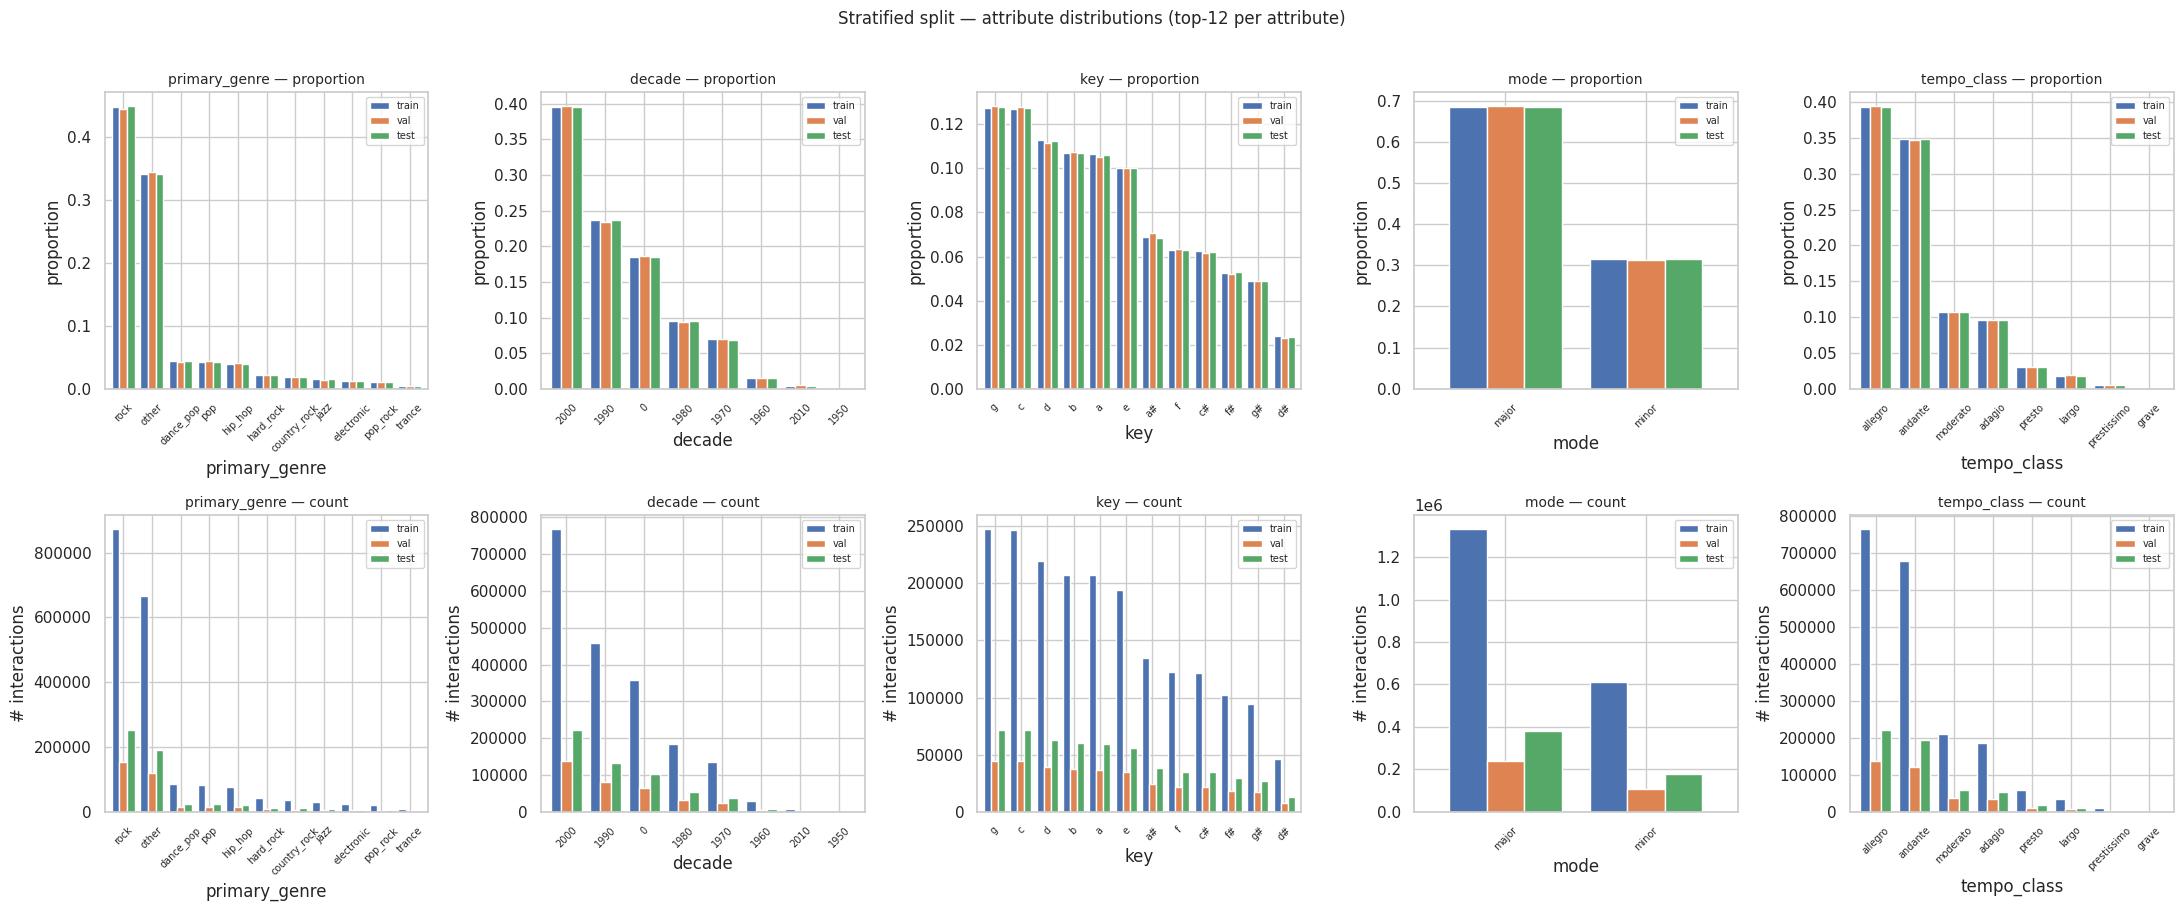

In [20]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm
from IPython.display import display

# Use the dedicated splitter module so the same logic is reusable from any model
from models.train_val_test_split import (
    DEFAULT_STRATA_ATTRS,
    COARSE_STRATA_ATTRS,
    build_song_strata,
    user_level_stratified_split,
    compute_split_distributions,
    plot_split_distributions,
    save_splits,
    load_splits,
)

TOP_N = 10
K_RANGE = range(5, 101, 5)
MIN_SONGS_PER_USER = 5
MIN_USERS_PER_SONG = 3

# ── 6.1 Encode IDs ───────────────────────────────────────────────────────────
merged_kg = pd.read_parquet(KG_INPUT_PQ)
taste_kg  = pd.read_parquet(KG_TASTE_PQ)
print(f"kg_input    : {merged_kg.shape}    cols incl. tempo_class={'tempo_class' in merged_kg.columns}")
print(f"kg_taste    : {taste_kg.shape}")

df = taste_kg.copy()
song_counts = df.groupby("song_id")["user_id"].nunique()
df = df[df["song_id"].isin(song_counts[song_counts >= MIN_USERS_PER_SONG].index)]
user_counts = df.groupby("user_id")["song_id"].nunique()
df = df[df["user_id"].isin(user_counts[user_counts >= MIN_SONGS_PER_USER].index)]

user_ids = sorted(df["user_id"].unique())
song_ids = sorted(df["song_id"].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}
song2idx = {s: i for i, s in enumerate(song_ids)}
idx2song = {i: s for s, i in song2idx.items()}
df["u_idx"] = df["user_id"].map(user2idx)
df["s_idx"] = df["song_id"].map(song2idx)
N_USERS, N_SONGS = len(user_ids), len(song_ids)
sparsity = 1.0 - len(df) / (N_USERS * N_SONGS)
print(f"Matrix: {N_USERS:,} users × {N_SONGS:,} songs  sparsity={sparsity:.4%}")

# ── 6.2 Per-user STRATIFIED 70/10/20 split ──────────────────────────────────
# Stratification axes: primary_genre × decade × key × mode × tempo_class
#
# Genre treatment:  `primary_genre` has ~272 unique levels.  We keep only the
# TOP_N_GENRES most common labels verbatim; all others are bucketed as "other".
# This halves the strata count (4,448 → ~2,186) with no change to the other
# axes and no loss of information on the dominant genres.
# To use all genres set TOP_N_GENRES = None.
#
# Small-stratum pooling: per-user (user × stratum) groups smaller than
# min_stratum_size=3 are *pooled* and re-split with the target ratios instead
# of being dumped wholesale into train, which recovers ≈70/10/20 globally.
STRATA_ATTRS     = DEFAULT_STRATA_ATTRS   # (primary_genre, decade, key, mode, tempo_class)
TOP_N_GENRES     = 10                     # set None to use all ~272 genres
SPLIT_PQ         = PROCESSED / "splits_stratified.parquet"
FINAL_SPLITS_DIR = FINAL / "splits"

# Build the song → stratum mapping
song_strata = build_song_strata(merged_kg, attrs=STRATA_ATTRS, top_n_genres=TOP_N_GENRES)
assert song_strata.index.is_unique, "song_strata index must be unique for .map() to work"

# Sanity-check of the per-attribute alphabet
_samp = song_strata.str.split("|", expand=True)
_samp.columns = list(STRATA_ATTRS)
print(f"\nStratification: {song_strata.nunique():,} unique strata over {len(song_strata):,} songs")
print(f"  (genre bucketed to top-{TOP_N_GENRES} + 'other')" if TOP_N_GENRES else "  (all genres)")
for col in _samp.columns:
    vals = sorted(_samp[col].dropna().unique())
    preview = vals[:6] + (["…"] if len(vals) > 6 else [])
    print(f"  {col:<14s} {_samp[col].nunique():>4d} unique  e.g. {preview}")

# ── Splits: load from cache or build ─────────────────────────────────────────
# NOTE: delete data/processed/splits_stratified.parquet (or set FORCE_REBUILD=True)
# if you change TOP_N_GENRES or STRATA_ATTRS, otherwise the cached file is used.
if SPLIT_PQ.exists() and not FORCE_REBUILD:
    splits_df = pd.read_parquet(SPLIT_PQ)
    train_df = df.loc[splits_df[splits_df.split == "train"].row_idx.values].copy()
    val_df   = df.loc[splits_df[splits_df.split == "val"  ].row_idx.values].copy()
    test_df  = df.loc[splits_df[splits_df.split == "test" ].row_idx.values].copy()
    train_df["stratum"] = train_df["song_id"].map(song_strata).fillna("_misc_")
    val_df["stratum"]   = val_df["song_id"].map(song_strata).fillna("_misc_")
    test_df["stratum"]  = test_df["song_id"].map(song_strata).fillna("_misc_")
    print(f"\n[SKIP] loaded stratified splits from {SPLIT_PQ}")
else:
    train_df, val_df, test_df = user_level_stratified_split(df, song_strata)
    pd.concat([
        pd.DataFrame({"row_idx": train_df.index, "split": "train"}),
        pd.DataFrame({"row_idx": val_df.index,   "split": "val"}),
        pd.DataFrame({"row_idx": test_df.index,  "split": "test"}),
    ], ignore_index=True).to_parquet(SPLIT_PQ, index=False)
    print(f"\n[SAVED] stratified row index → {SPLIT_PQ}")

total = len(df)
print(f"Train={len(train_df):,} ({len(train_df)/total:.1%})  "
      f"Val={len(val_df):,} ({len(val_df)/total:.1%})  "
      f"Test={len(test_df):,} ({len(test_df)/total:.1%})  "
      f"(target 70/10/20)")

# Persist the actual split DataFrames to data/final/splits/ as parquet
splits_dict = {"train": train_df, "val": val_df, "test": test_df}
saved_paths = save_splits(
    splits_dict, FINAL_SPLITS_DIR, fmt="parquet",
    metadata={
        "attrs": list(STRATA_ATTRS),
        "top_n_genres": TOP_N_GENRES,
        "n_users": N_USERS, "n_songs": N_SONGS,
        "n_strata": int(song_strata.nunique()),
        "kg_input_path": str(KG_INPUT_PQ),
        "kg_taste_path": str(KG_TASTE_PQ),
        "min_users_per_song": MIN_USERS_PER_SONG,
        "min_songs_per_user": MIN_SONGS_PER_USER,
    },
)
print("Final splits written to:")
for k, p in saved_paths.items():
    print(f"  {k:5s} → {p.relative_to(ROOT)}")

# ── 6.2.1 Distribution diagnostics (DataFrames + JS-divergence) ─────────────
distributions = compute_split_distributions(splits_dict, song_strata, attr_names=STRATA_ATTRS)

print("\n══ Jensen-Shannon divergence vs. train  (0 = perfectly balanced) ════")
display(distributions["js_div"])

print("\n══ Top-12 levels per attribute — proportion in each split ═══════════")
for attr, dist_table in distributions["proportion"].items():
    print(f"\n── {attr.upper()} ──")
    display(dist_table.head(12))

# ── 6.2.2 Distribution plots (proportion + count) ───────────────────────────
fig = plot_split_distributions(distributions, top_k=12)
plt.show()

# ── 6.2.3 Build sparse train matrix + ground-truth dicts ────────────────────
train_matrix      = csr_matrix((np.ones(len(train_df)), (train_df["u_idx"].values, train_df["s_idx"].values)),
                                shape=(N_USERS, N_SONGS), dtype=np.float32)
train_matrix_norm = normalize(train_matrix, norm="l2")
song_popularity   = np.asarray(train_matrix.sum(axis=0)).ravel()
pop_norm          = song_popularity / (song_popularity.max() + 1e-9)

def make_gt(split_df): return split_df.groupby("u_idx")["s_idx"].apply(set).to_dict()
val_gt  = make_gt(val_df);  test_gt = make_gt(test_df)
train_seen = train_df.groupby("u_idx")["s_idx"].apply(set).to_dict()
val_users  = sorted(val_gt.keys()); test_users = sorted(test_gt.keys())

# Keep `merged` and `taste` aliases for the rest of the notebook
merged = merged_kg
taste  = taste_kg


In [21]:
def dcg(hits):
    hits = np.asarray(hits, dtype=float)
    return float(np.sum(hits / np.log2(np.arange(2, len(hits)+2)))) if hits.sum() else 0.0

def evaluate_recs(recs_dict, ground_truth, seen_dict, n_songs, k=TOP_N):
    recalls, ndcgs, hits, rrs, pops = [], [], [], [], []
    rec_set = set()
    for u, rec in recs_dict.items():
        gt = ground_truth.get(u, set())
        if not gt: continue
        top = rec[:k]
        h = [1 if s in gt else 0 for s in top]
        recalls.append(len(set(top) & gt) / min(len(gt), k))
        ndcgs.append(dcg(h) / (dcg(sorted(h, reverse=True)) + 1e-9))
        hits.append(float(any(s in gt for s in top)))
        rrs.append(next((1/(r+1) for r,s in enumerate(top) if s in gt), 0.0))
        pops.append(float(np.mean(pop_norm[list(top)])) if top else 0.0)
        rec_set.update(top)
    return {"Recall@K": float(np.mean(recalls)), "NDCG@K": float(np.mean(ndcgs)),
            "HitRate@K": float(np.mean(hits)), "MRR": float(np.mean(rrs)),
            "Coverage": len(rec_set)/n_songs, "PopularityBias": float(np.mean(pops))}

def overall_score(m):
    return 0.35*m["Recall@K"] + 0.35*m["NDCG@K"] + 0.20*m["Coverage"] + 0.10*(1-m["PopularityBias"])

# ── 6.3 KNN sweep or load from cache ─────────────────────────────────────────
if KNN_VAL_CSV.exists() and KNN_TEST_CSV.exists() and not FORCE_REBUILD:
    val_results_df = pd.read_csv(KNN_VAL_CSV, index_col=0)
    test_summary   = pd.read_csv(KNN_TEST_CSV).iloc[0].to_dict()
    best_k         = int(test_summary["best_k"])
    test_metrics   = {k: test_summary[k] for k in ("Recall@K","NDCG@K","HitRate@K","MRR","Coverage","PopularityBias","Overall_Score")}
    print(f"[SKIP] KNN results loaded. best_k={best_k}  test Recall@{TOP_N}={test_metrics['Recall@K']:.4f}")
else:
    MAX_K = max(K_RANGE)
    knn = NearestNeighbors(n_neighbors=MAX_K+1, metric="cosine", algorithm="brute", n_jobs=-1)
    knn.fit(train_matrix_norm)
    all_query = sorted(set(val_users) | set(test_users))
    _, all_nbrs = knn.kneighbors(train_matrix_norm[all_query], n_neighbors=MAX_K+1)
    qrow = {u: i for i, u in enumerate(all_query)}

    def get_recs(k, user_list):
        out = {}
        for u in user_list:
            nbrs = [x for x in all_nbrs[qrow[u]] if x != u][:k]
            if not nbrs: out[u] = []; continue
            sc = np.asarray(train_matrix_norm[nbrs].sum(axis=0)).ravel()
            for s in train_seen.get(u, set()): sc[s] = 0.0
            top = np.argpartition(sc, -TOP_N)[-TOP_N:]
            out[u] = top[np.argsort(sc[top])[::-1]].tolist()
        return out

    val_results = []
    for k in tqdm(K_RANGE, desc="k-sweep (val)"):
        m = evaluate_recs(get_recs(k, val_users), val_gt, train_seen, N_SONGS)
        m["k"] = k; m["Overall_Score"] = overall_score(m); val_results.append(m)
    val_results_df = pd.DataFrame(val_results).set_index("k")
    best_k = int(val_results_df["Overall_Score"].idxmax())

    test_recs    = get_recs(best_k, test_users)
    test_metrics = evaluate_recs(test_recs, test_gt, train_seen, N_SONGS)
    test_metrics["Overall_Score"] = overall_score(test_metrics)

    val_results_df.to_csv(KNN_VAL_CSV)
    pd.DataFrame([{"best_k": best_k, **test_metrics,
                   "n_users": N_USERS, "n_songs": N_SONGS,
                   "train_interactions": len(train_df), "val_interactions": len(val_df),
                   "test_interactions": len(test_df)}]).to_csv(KNN_TEST_CSV, index=False)
    print(f"best_k={best_k}  test Recall@{TOP_N}={test_metrics['Recall@K']:.4f}")

[SKIP] KNN results loaded. best_k=20  test Recall@10=0.1615


[SAVED] pop/KNN metrics → /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/knn_pop_metrics.csv
KNN vs MostPopular — TEST set
                MostPopular  KNN (k=20)  Δ KNN−Pop
Recall@K             0.1285      0.1615     0.0330
NDCG@K               0.1143      0.1635     0.0492
HitRate@K            0.2002      0.2508     0.0506
MRR                  0.0895      0.1382     0.0487
Coverage             0.0064      0.8548     0.8484
PopularityBias       0.6110      0.2132    -0.3978
Overall_Score        0.1252      0.3634     0.2382
[SAVED] validation sweep plot → /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/knn_val_sweep.png
[SAVED] validation sweep plot → /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/knn_val_sweep.png


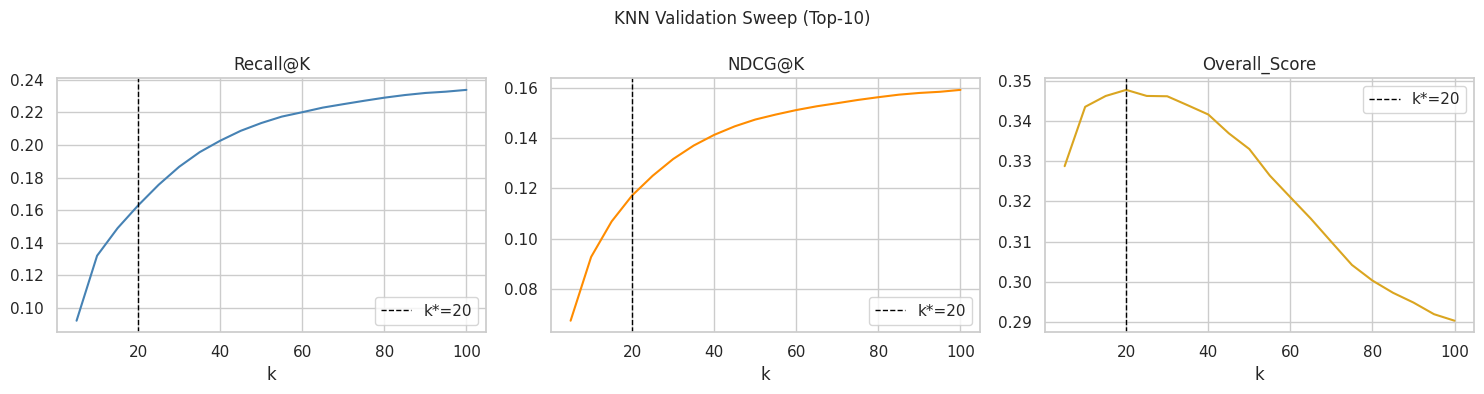

In [22]:
import json

KNN_POP_CSV      = PROCESSED / "knn_pop_metrics.csv"       # comparison table
KNN_POP_JSON     = PROCESSED / "knn_pop_metrics.json"      # raw dicts for downstream cells
KNN_VAL_PLOT_PNG = PROCESSED / "knn_val_sweep.png"         # validation sweep figure

# ── 6.4  MostPopular baseline + comparison ───────────────────────────────────
if KNN_POP_JSON.exists() and not FORCE_REBUILD:
    with open(KNN_POP_JSON) as f:
        _saved = json.load(f)
    pop_metrics  = _saved["pop_metrics"]
    test_metrics = _saved["test_metrics"]   # re-sync in case cell 17 was skipped
    best_k       = int(_saved["best_k"])
    comparison   = pd.read_csv(KNN_POP_CSV, index_col=0)
    print(f"[SKIP] loaded pop/KNN metrics from {KNN_POP_JSON}")
else:
    pop_rank = np.argsort(-song_popularity)
    pop_recs = {
        u: [int(i) for i in pop_rank if int(i) not in train_seen.get(u, set())][:TOP_N]
        for u in test_users
    }
    pop_metrics = evaluate_recs(pop_recs, test_gt, train_seen, N_SONGS)
    pop_metrics["Overall_Score"] = overall_score(pop_metrics)

    comparison = pd.DataFrame(
        {"MostPopular": pop_metrics, f"KNN (k={best_k})": test_metrics}
    ).round(4)
    comparison[f"Δ KNN−Pop"] = (
        comparison[f"KNN (k={best_k})"] - comparison["MostPopular"]
    ).round(4)

    # ── save ──────────────────────────────────────────────────────────────────
    comparison.to_csv(KNN_POP_CSV)
    with open(KNN_POP_JSON, "w") as f:
        json.dump({"pop_metrics": pop_metrics,
                   "test_metrics": test_metrics,
                   "best_k": best_k}, f, indent=2)
    print(f"[SAVED] pop/KNN metrics → {KNN_POP_CSV}")

print("KNN vs MostPopular — TEST set")
print(comparison.to_string())

# ── 6.5  Validation sweep plots ───────────────────────────────────────────────
if KNN_VAL_PLOT_PNG.exists() and not FORCE_REBUILD:
    from IPython.display import Image as IPImage
    print(f"[SKIP] showing saved validation sweep plot from {KNN_VAL_PLOT_PNG}")
    display(IPImage(str(KNN_VAL_PLOT_PNG)))
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (col, color) in zip(axes, [
        ("Recall@K",      "steelblue"),
        ("NDCG@K",        "darkorange"),
        ("Overall_Score", "goldenrod"),
    ]):
        ax.plot(val_results_df.index, val_results_df[col], color=color)
        ax.axvline(best_k, color="black", linestyle="--", linewidth=1,
                   label=f"k*={best_k}")
        ax.set_title(col); ax.set_xlabel("k"); ax.legend()
    plt.suptitle(f"KNN Validation Sweep (Top-{TOP_N})", fontsize=12)
    plt.tight_layout()
    fig.savefig(KNN_VAL_PLOT_PNG, dpi=120, bbox_inches="tight")
    print(f"[SAVED] validation sweep plot → {KNN_VAL_PLOT_PNG}")
    plt.show()


## 6.6 — Stratified K-Fold Cross-Validation (KNN baseline)
Per-user stratified K-fold (k = 5) on the same genre × decade × key × mode strata. Reports mean ± std for each metric so we know the variance of the baseline before comparing to the GNN.

[SKIP] loaded K-fold results from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/knn_cf_kfold_results.csv

══ 5-Fold CV Summary (KNN k=20, Top-10) ═════════════════════
                     mean ± std
Recall@K        0.1901 ± 0.1907
NDCG@K          0.1340 ± 0.1299
HitRate@K       0.2008 ± 0.1856
MRR             0.1134 ± 0.1131
Coverage        0.1989 ± 0.2338
PopularityBias  0.1324 ± 0.0937
Overall_Score   0.2400 ± 0.1149


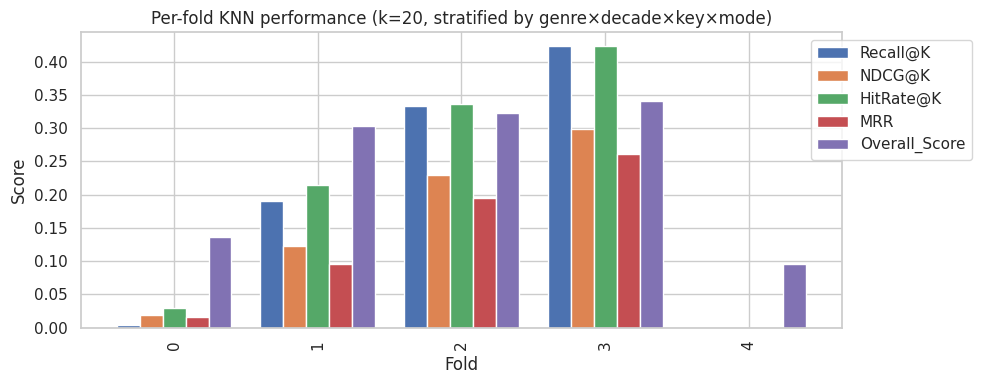

In [23]:
N_FOLDS = 5
KFOLD_CSV = PROCESSED / "knn_cf_kfold_results.csv"

def user_level_stratified_kfold(df, song_strata, n_folds=5, seed=42):
    """Per-user, per-stratum round-robin K-fold assignment.
    Returns array of length len(df) with fold ids in 0..n_folds-1."""
    rng = np.random.default_rng(seed)
    df = df.copy()
    df["stratum"] = df["song_id"].map(song_strata).fillna("_misc_")
    fold_assign = np.full(len(df), -1, dtype=np.int8)
    pos = {idx: i for i, idx in enumerate(df.index)}
    for _, grp in df.groupby("u_idx"):
        for _, sgrp in grp.groupby("stratum"):
            idxs = sgrp.index.to_numpy()
            shuffled = rng.permutation(idxs)
            for i, idx in enumerate(shuffled):
                fold_assign[pos[idx]] = i % n_folds
    return pd.Series(fold_assign, index=df.index, name="fold")

if KFOLD_CSV.exists() and not FORCE_REBUILD:
    fold_results_df = pd.read_csv(KFOLD_CSV)
    print(f"[SKIP] loaded K-fold results from {KFOLD_CSV}")
else:
    folds = user_level_stratified_kfold(df, song_strata, n_folds=N_FOLDS)
    fold_results = []
    for fold in range(N_FOLDS):
        test_idx  = folds[folds == fold].index
        train_idx = folds[folds != fold].index
        f_train = df.loc[train_idx]; f_test = df.loc[test_idx]

        f_mat = csr_matrix((np.ones(len(f_train)), (f_train["u_idx"].values, f_train["s_idx"].values)),
                           shape=(N_USERS, N_SONGS), dtype=np.float32)
        f_mat_n = normalize(f_mat, norm="l2")
        f_seen  = f_train.groupby("u_idx")["s_idx"].apply(set).to_dict()
        f_gt    = f_test.groupby("u_idx")["s_idx"].apply(set).to_dict()
        f_users = sorted(f_gt.keys())

        knn_f = NearestNeighbors(n_neighbors=best_k + 1, metric="cosine", algorithm="brute", n_jobs=-1)
        knn_f.fit(f_mat_n)
        _, nbrs = knn_f.kneighbors(f_mat_n[f_users], n_neighbors=best_k + 1)
        qrow = {u: i for i, u in enumerate(f_users)}

        recs = {}
        for u in f_users:
            nb = [x for x in nbrs[qrow[u]] if x != u][:best_k]
            if not nb:
                recs[u] = []; continue
            sc = np.asarray(f_mat_n[nb].sum(axis=0)).ravel()
            for s in f_seen.get(u, set()): sc[s] = 0.0
            top = np.argpartition(sc, -TOP_N)[-TOP_N:]
            recs[u] = top[np.argsort(sc[top])[::-1]].tolist()

        m = evaluate_recs(recs, f_gt, f_seen, N_SONGS)
        m["Overall_Score"] = overall_score(m); m["fold"] = fold
        fold_results.append(m)
        print(f"  fold {fold}:  Recall@{TOP_N}={m['Recall@K']:.4f}  NDCG={m['NDCG@K']:.4f}  Overall={m['Overall_Score']:.4f}")

    fold_results_df = pd.DataFrame(fold_results)
    fold_results_df.to_csv(KFOLD_CSV, index=False)
    print(f"[SAVED] K-fold results → {KFOLD_CSV}")

metric_cols = ["Recall@K", "NDCG@K", "HitRate@K", "MRR", "Coverage", "PopularityBias", "Overall_Score"]
summary = fold_results_df[metric_cols].agg(["mean", "std"]).T
summary.columns = ["mean", "std"]
summary["mean ± std"] = summary.apply(lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
print(f"\n══ {N_FOLDS}-Fold CV Summary (KNN k={best_k}, Top-{TOP_N}) ═════════════════════")
print(summary[["mean ± std"]].to_string())

# Plot per-fold variance
fig, ax = plt.subplots(figsize=(10, 4))
plot_metrics = ["Recall@K", "NDCG@K", "HitRate@K", "MRR", "Overall_Score"]
fold_results_df[plot_metrics].plot.bar(ax=ax, width=0.8)
ax.set_xlabel("Fold"); ax.set_ylabel("Score")
ax.set_title(f"Per-fold KNN performance (k={best_k}, stratified by genre×decade×key×mode)")
ax.legend(loc="upper right", bbox_to_anchor=(1.18, 1))
plt.tight_layout(); plt.show()

## 6.7 — Qualitative Analysis: Example User
Pick one user with enough listening history; show (a) their training songs as the *reference profile*, then (b) the top-K KNN recommendations along with their **cosine similarity** to the user's profile vector and to each individual reference song.

Example user: u_idx=25796  user_id=176bf288683632f5aed6a7f26b14bb5fac5a88ea
  train interactions : 18
  test  interactions : 5

── Reference: top-10 training songs (by play count) for u_idx=25796 ──


,title,artist,genre,year,key,mode,tempo_class,mean_tempo
song_id,,,,,,,,
SOQPGLL12A58A7CDD2,Time (LP Version),Hootie And The Blowfish,rock,NaN,D,major,Moderato,108.2
SOJFOFI12AB0180132,Aqui No Es Asi,Caifanes,rock,1994.0,F,major,Andante,105.0
SOVALQH12AB0189114,My Sacrifice,Creed,rock,NaN,D,major,Adagio,74.0
SONGABP12A8C1442D4,Interstate Love Song (LP Version),Stone Temple Pilots,rock,2003.0,A,major,Andante,81.0
SOLLNTU12A6701CFDC,Kryptonite,3 Doors Down,rock,1997.0,G,major,Andante,99.0
SORNYNX12A6BD56BAC,Clear,Cybertron,electro,1983.0,C#,minor,Allegro,125.0
SOUVYVR12A8C13B19B,Let Her Cry (LP Version),Hootie And The Blowfish,rock,1994.0,G,major,Adagio,70.0
SOKZICY12A6310DF57,Always,Blink-182,power pop,2003.0,B,major,Allegro,158.0
SOHEMBB12A6701E907,Superman,Eminem / Dina Rae,hip hop,2003.0,E,minor,Adagio,68.0



── Top-10 KNN recommendations (k=20) for u_idx=25796 ──


,title,artist,genre,year,key,mode,tempo_class,knn_score,cos(user),cos(refs)_mean,cos(refs)_max,nearest_ref,in_test_gt
rank,,,,,,,,,,,,,
1,Feeling This,Blink-182,power pop,2003.0,F#,minor,Andante,1.0000,0.1079,0.0330,0.2804,Always — Blink-182,False
2,Roller Coaster,Blink-182,power pop,2001.0,D,major,Prestissimo,0.8536,0.0537,0.0187,0.1598,Going Away To College — Blink-182,True
3,Anthem Part Two,Blink-182,power pop,2006.0,C,major,Prestissimo,0.7315,0.0439,0.0145,0.1153,Going Away To College — Blink-182,True
4,Snow [Hey Oh] (Album Version),Red Hot Chili Peppers,rock,NaN,B,major,Andante,0.5000,0.0467,0.0111,0.0263,Kryptonite — 3 Doors Down,False
5,You're The One,Dwight Yoakam,rock,1990.0,G,major,Allegro,0.5000,0.2334,0.0358,0.2840,Horn Concerto No. 4 in E flat K495: II. Romanc...,False
6,Temperature (Album Version),Sean Paul,dancehall,2005.0,A#,major,Allegro,0.5000,0.0337,0.0064,0.0251,Horn Concerto No. 4 in E flat K495: II. Romanc...,False
7,Video Killed The Radio Star,The Buggles,new wave,1979.0,C#,major,Allegro,0.5000,0.0821,0.0146,0.0815,Horn Concerto No. 4 in E flat K495: II. Romanc...,False
8,Secrets,OneRepublic,rock,2009.0,B,minor,Allegro,0.5000,0.2024,0.0345,0.1696,Horn Concerto No. 4 in E flat K495: II. Romanc...,False
9,Lady Marmalade,Christina Aguilera / Lil' Kim / Mya / Pink,dance pop,2004.0,F,major,Moderato,0.5000,0.0333,0.0069,0.0205,Horn Concerto No. 4 in E flat K495: II. Romanc...,False


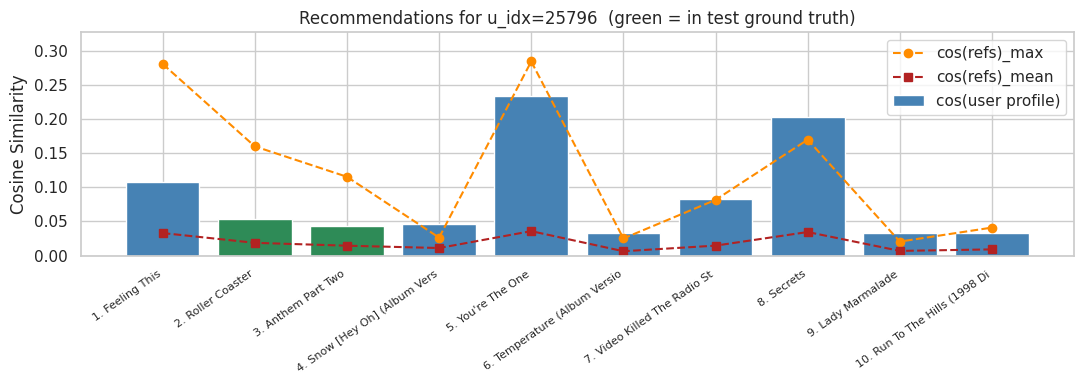


══════════════════════════════════════════════════════════════════════
6.7.7  Profile statistics — train | recs | test ground-truth
══════════════════════════════════════════════════════════════════════

── Cosine similarity (rec → user profile) ───────────────────────────


,value
metric,
mean,0.0871
median,0.0502
min,0.0333
max,0.2334
# in test gt,2 / 10



── GENRE distribution ──────────────────────────────────


,train,recs,test_gt
genre,,,
rock,0.667,0.3,0.2
power pop,0.111,0.3,0.4
hard rock,0.056,0.0,0.0
electro,0.056,0.0,0.0
hip hop,0.056,0.0,0.4
unk,0.056,0.0,0.0
dancehall,0.000,0.1,0.0
new wave,0.000,0.1,0.0
dance pop,0.000,0.1,0.0



── MODE distribution ──────────────────────────────────


,train,recs,test_gt
mode,,,
major,0.722,0.8,0.8
minor,0.278,0.2,0.2



── TEMPO_CLASS distribution ──────────────────────────────────


,train,recs,test_gt
tempo_class,,,
Allegro,0.389,0.5,0.2
Andante,0.222,0.2,0.4
Adagio,0.167,0.0,0.0
Moderato,0.111,0.1,0.0
Presto,0.056,0.0,0.0
Largo,0.056,0.0,0.0
Prestissimo,0.000,0.2,0.4


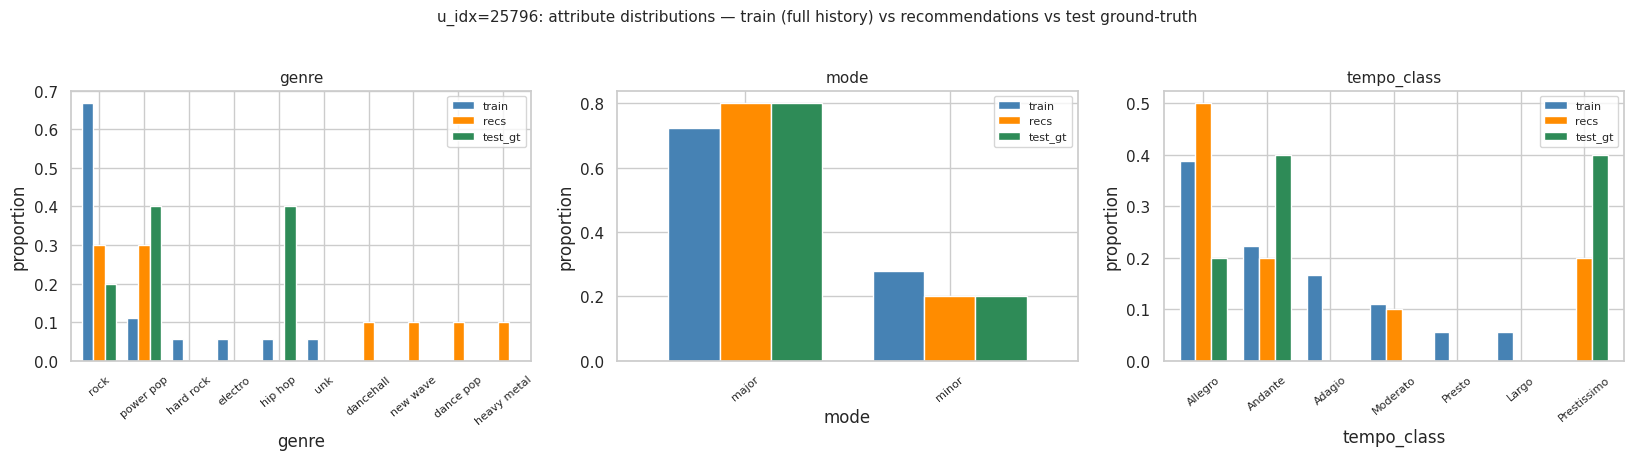


── Year / decade distribution ───────────────────────────────────────


,train,recs,test_gt
year,,,
1980,0.154,0.111,0.0
1990,0.308,0.111,0.0
2000,0.538,0.667,1.0
1970,0.000,0.111,0.0


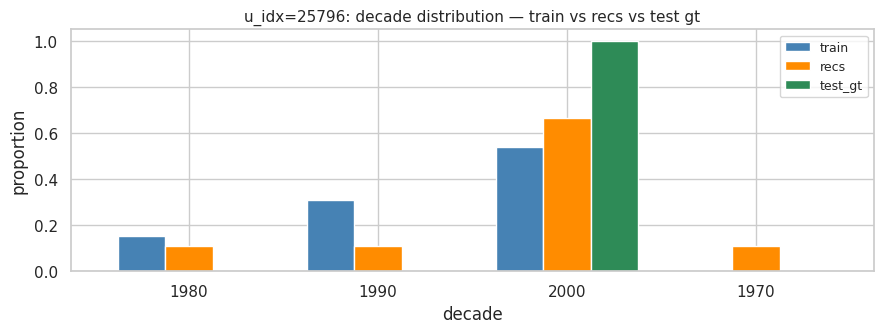


── Numeric feature means (train | recs | test gt) ───────────────────


,train,recs,test_gt
feature,,,
mean tempo (BPM),113.04,142.82,153.6
mean year,1997.85,1997.67,2002.2



── Verdict ──────────────────────────────────────────────────────────
  KNN hit 2/10 test-ground-truth songs in the top-10.
  User's dominant train genre : rock
  Dominant genre in recs      : power pop  (✗ mismatch)
  Mean cos(rec → profile)     : 0.0871  (purely from interaction counts — no audio features used)


In [24]:
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import HTML

# ── 6.7.1 Pick an example user (median listening volume in test set) ─────────
user_train_sizes = train_df.groupby("u_idx").size()
candidates = [u for u in test_users if 15 <= user_train_sizes.get(u, 0) <= 60]
example_uidx = int(np.random.default_rng(42).choice(candidates)) if candidates else int(test_users[0])
example_uid  = user_ids[example_uidx]
print(f"Example user: u_idx={example_uidx}  user_id={example_uid}")
print(f"  train interactions : {user_train_sizes.get(example_uidx, 0)}")
print(f"  test  interactions : {len(test_gt.get(example_uidx, set()))}")

# Helper: song_id → metadata row
song_meta = (
    merged[["song_id", "title", "artist_name", "primary_genre",
            "year", "key", "mode", "Mean_Tempo", "tempo_class"]]
    .drop_duplicates("song_id")
    .set_index("song_id")
)

def _meta_row(s_idx):
    sid = idx2song[int(s_idx)]
    if sid in song_meta.index:
        r = song_meta.loc[sid]
        return {"song_id": sid, "title": r["title"], "artist": r["artist_name"],
                "genre": r["primary_genre"], "year": int(r["year"]) if pd.notna(r["year"]) else np.nan,
                "key": r["key"], "mode": r["mode"], "tempo_class": r["tempo_class"],
                "mean_tempo": round(float(r["Mean_Tempo"]), 1) if pd.notna(r["Mean_Tempo"]) else np.nan}
    return {"song_id": sid, "title": "<unknown>", "artist": "?", "genre": "?",
            "year": np.nan, "key": np.nan, "mode": np.nan, "tempo_class": "?", "mean_tempo": np.nan}

# ── 6.7.2 Reference: user's training history (top by play count) ─────────────
user_train = train_df[train_df.u_idx == example_uidx].copy()
user_train_top = (user_train.sort_values("play_count", ascending=False).head(10)
                  if "play_count" in user_train.columns else user_train.head(10))
ref_table = pd.DataFrame([_meta_row(s) for s in user_train_top.s_idx])
print(f"\n── Reference: top-10 training songs (by play count) for u_idx={example_uidx} ──")
display(ref_table.set_index("song_id"))

# ── 6.7.3 Build user profile vector ─────────────────────────────────────────
ref_s_idxs  = list(train_seen.get(example_uidx, set()))
song_vectors = train_matrix_norm.T.tocsr()      # shape: (N_SONGS, N_USERS)
profile_vec  = np.asarray(song_vectors[ref_s_idxs].mean(axis=0)).reshape(1, -1)

# ── 6.7.4 Generate KNN recommendations ──────────────────────────────────────
knn_q = NearestNeighbors(n_neighbors=best_k + 1, metric="cosine", algorithm="brute", n_jobs=-1)
knn_q.fit(train_matrix_norm)
_, nbrs_q = knn_q.kneighbors(train_matrix_norm[example_uidx], n_neighbors=best_k + 1)
nbrs_q = [x for x in nbrs_q[0].tolist() if x != example_uidx][:best_k]
scores = np.asarray(train_matrix_norm[nbrs_q].sum(axis=0)).ravel()
for s in train_seen.get(example_uidx, set()):
    scores[s] = 0.0
top_idxs = np.argpartition(scores, -TOP_N)[-TOP_N:]
top_idxs = top_idxs[np.argsort(scores[top_idxs])[::-1]]

# ── 6.7.5 Cosine similarities ────────────────────────────────────────────────
rec_vectors  = song_vectors[top_idxs.tolist()].toarray()
cos_to_user  = cosine_similarity(profile_vec, rec_vectors).ravel()
ref_vectors  = song_vectors[ref_s_idxs].toarray()
cos_to_refs  = cosine_similarity(rec_vectors, ref_vectors)
mean_cos_ref = cos_to_refs.mean(axis=1)
max_cos_ref  = cos_to_refs.max(axis=1)
nearest_ref  = [ref_s_idxs[i] for i in cos_to_refs.argmax(axis=1)]
hit_set      = test_gt.get(example_uidx, set())

rec_rows = []
for rank, (s_idx, c_user, c_mean, c_max, near_s) in enumerate(
        zip(top_idxs, cos_to_user, mean_cos_ref, max_cos_ref, nearest_ref), start=1):
    m = _meta_row(int(s_idx))
    near_meta = _meta_row(int(near_s))
    rec_rows.append({
        "rank": rank,
        "title": m["title"], "artist": m["artist"], "genre": m["genre"],
        "year": m["year"], "key": m["key"], "mode": m["mode"],
        "tempo_class": m["tempo_class"],
        "knn_score":      round(float(scores[s_idx]), 4),
        "cos(user)":      round(float(c_user), 4),
        "cos(refs)_mean": round(float(c_mean), 4),
        "cos(refs)_max":  round(float(c_max), 4),
        "nearest_ref":    f"{near_meta['title']} — {near_meta['artist']}",
        "in_test_gt":     int(s_idx) in hit_set,
    })
rec_table = pd.DataFrame(rec_rows)

print(f"\n── Top-{TOP_N} KNN recommendations (k={best_k}) for u_idx={example_uidx} ──")
display(rec_table.set_index("rank"))

# ── 6.7.6 Per-recommendation bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
labels = [f"{r['rank']}. {r['title'][:25]}" for _, r in rec_table.iterrows()]
colors = ["seagreen" if r["in_test_gt"] else "steelblue" for _, r in rec_table.iterrows()]
ax.bar(range(len(rec_table)), rec_table["cos(user)"], color=colors, label="cos(user profile)")
ax.plot(range(len(rec_table)), rec_table["cos(refs)_max"],  "o--", color="darkorange", label="cos(refs)_max")
ax.plot(range(len(rec_table)), rec_table["cos(refs)_mean"], "s--", color="firebrick",  label="cos(refs)_mean")
ax.set_xticks(range(len(rec_table)))
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Cosine Similarity")
ax.set_ylim(0, max(0.05, rec_table[["cos(user)", "cos(refs)_max"]].values.max() * 1.15))
ax.set_title(f"Recommendations for u_idx={example_uidx}  (green = in test ground truth)")
ax.legend()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6.7.7  Profile statistics: train vs recommendations vs test ground-truth
# ═══════════════════════════════════════════════════════════════════════════════
# Build metadata tables for the three item sets
train_all_meta  = pd.DataFrame([_meta_row(s) for s in ref_s_idxs])
rec_meta        = rec_table[["genre", "year", "key", "mode", "tempo_class",
                              "cos(user)", "cos(refs)_mean", "knn_score"]].copy()
test_s_idxs     = list(hit_set)
test_meta       = pd.DataFrame([_meta_row(s) for s in test_s_idxs]) if test_s_idxs else pd.DataFrame()

print("\n" + "═" * 70)
print("6.7.7  Profile statistics — train | recs | test ground-truth")
print("═" * 70)

# ── Cosine-similarity summary ─────────────────────────────────────────────────
print("\n── Cosine similarity (rec → user profile) ───────────────────────────")
cos_summary = pd.DataFrame({
    "metric": ["mean", "median", "min", "max", "# in test gt"],
    "value": [
        f"{cos_to_user.mean():.4f}",
        f"{np.median(cos_to_user):.4f}",
        f"{cos_to_user.min():.4f}",
        f"{cos_to_user.max():.4f}",
        f"{rec_table['in_test_gt'].sum()} / {TOP_N}",
    ]
}).set_index("metric")
display(cos_summary)

# ── Attribute distribution comparisons ───────────────────────────────────────
PROFILE_ATTRS = ["genre", "mode", "tempo_class"]

def _freq_table(df, col, label):
    if df.empty or col not in df.columns:
        return pd.Series(dtype=float).rename(label)
    return (df[col].fillna("unk").value_counts(normalize=True)
                   .round(3).rename(label))

fig, axes = plt.subplots(1, len(PROFILE_ATTRS),
                          figsize=(5.5 * len(PROFILE_ATTRS), 4.5))
if len(PROFILE_ATTRS) == 1:
    axes = [axes]

for ax, attr in zip(axes, PROFILE_ATTRS):
    s_train = _freq_table(train_all_meta, attr, "train")
    s_rec   = _freq_table(rec_meta,       attr, "recs")
    s_test  = _freq_table(test_meta,      attr, "test_gt") if not test_meta.empty else pd.Series(dtype=float).rename("test_gt")

    comp = (pd.concat([s_train, s_rec, s_test], axis=1)
              .fillna(0)
              .sort_values("train", ascending=False))

    comp.plot.bar(ax=ax, width=0.75,
                  color=["steelblue", "darkorange", "seagreen"])
    ax.set_title(attr, fontsize=11)
    ax.set_ylabel("proportion")
    ax.tick_params(axis="x", rotation=40, labelsize=8)
    ax.legend(fontsize=8)

    # Print the table too
    print(f"\n── {attr.upper()} distribution ──────────────────────────────────")
    display(comp.round(3))

fig.suptitle(
    f"u_idx={example_uidx}: attribute distributions — "
    "train (full history) vs recommendations vs test ground-truth",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Year / decade distribution ────────────────────────────────────────────────
print("\n── Year / decade distribution ───────────────────────────────────────")
def _decade_dist(df, label):
    if df.empty or "year" not in df.columns:
        return pd.Series(dtype=float).rename(label)
    d = ((pd.to_numeric(df["year"], errors="coerce").dropna()
            .astype(int) // 10 * 10)
           .value_counts(normalize=True)
           .sort_index()
           .round(3)
           .rename(label))
    d.index = d.index.astype(str)
    return d

decade_comp = (pd.concat([
    _decade_dist(train_all_meta, "train"),
    _decade_dist(rec_meta,       "recs"),
    _decade_dist(test_meta,      "test_gt") if not test_meta.empty else pd.Series(dtype=float).rename("test_gt"),
], axis=1).fillna(0))
display(decade_comp.round(3))

fig2, ax2 = plt.subplots(figsize=(9, 3.5))
decade_comp.plot.bar(ax=ax2, width=0.75,
                     color=["steelblue", "darkorange", "seagreen"])
ax2.set_title(f"u_idx={example_uidx}: decade distribution — train vs recs vs test gt", fontsize=11)
ax2.set_xlabel("decade"); ax2.set_ylabel("proportion")
ax2.tick_params(axis="x", rotation=0)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Numeric summary (mean_tempo, year) ────────────────────────────────────────
print("\n── Numeric feature means (train | recs | test gt) ───────────────────")
num_summary_rows = []
for feat, label in [("mean_tempo", "mean tempo (BPM)"), ("year", "mean year")]:
    row = {"feature": label}
    for df_, split in [(train_all_meta, "train"), (rec_meta if feat in rec_meta.columns else pd.DataFrame(), "recs"),
                       (test_meta, "test_gt")]:
        if not df_.empty and feat in df_.columns:
            vals = pd.to_numeric(df_[feat], errors="coerce").dropna()
            row[split] = round(float(vals.mean()), 2) if len(vals) else float("nan")
        else:
            row[split] = float("nan")
    num_summary_rows.append(row)

# re-attach mean_tempo to rec_meta from rec_table original data
rec_full_meta = pd.DataFrame([_meta_row(int(s)) for s in top_idxs])
for feat, label in [("mean_tempo", "mean tempo (BPM)"), ("year", "mean year")]:
    num_summary_rows_fixed = []
    for row in num_summary_rows:
        if row["feature"] == label:
            vals = pd.to_numeric(rec_full_meta.get(feat, pd.Series(dtype=float)), errors="coerce").dropna()
            row["recs"] = round(float(vals.mean()), 2) if len(vals) else float("nan")
        num_summary_rows_fixed.append(row)
    num_summary_rows = num_summary_rows_fixed

display(pd.DataFrame(num_summary_rows).set_index("feature"))

# ── Plain-English verdict ──────────────────────────────────────────────────────
n_hits = int(rec_table["in_test_gt"].sum())
top_genre_train = train_all_meta["genre"].mode()[0] if not train_all_meta.empty else "?"
top_genre_rec   = rec_full_meta["genre"].mode()[0]  if not rec_full_meta.empty else "?"
dominant_match  = top_genre_train.lower() == top_genre_rec.lower()

print("\n── Verdict ──────────────────────────────────────────────────────────")
print(f"  KNN hit {n_hits}/{TOP_N} test-ground-truth songs in the top-{TOP_N}.")
print(f"  User's dominant train genre : {top_genre_train}")
print(f"  Dominant genre in recs      : {top_genre_rec}  "
      f"({'✓ match' if dominant_match else '✗ mismatch'})")
print(f"  Mean cos(rec → profile)     : {cos_to_user.mean():.4f}  "
      f"(purely from interaction counts — no audio features used)")


## 6.8 — Population-Level Qualitative Analysis
Runs the same profile-vs-recommendations comparison across **all test users** to see whether the collaborative-filtering KNN (which saw *only interaction counts*, no music features) produces recommendations whose musical attributes align with what users actually listened to.

For every test user we compare:
- **train** — the user's full training history  
- **recs** — the KNN top-10 recommendations  
- **test gt** — the held-out ground-truth songs

We aggregate: (1) per-user JS-divergence between train and recs distributions, (2) dominant-genre match rate, (3) mode & tempo-class alignment, (4) decade shift, (5) cosine-similarity distribution across all users, and (6) a population-level attribute comparison that shows how faithfully recommendations mirror training profiles — **without any audio features**.


Building attribute lookup arrays …  done.
done.
[SKIP] loaded /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/pop_qual_analysis.csv  (284,864 users)

284,864 test users analysed
[SKIP] loaded /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/pop_qual_analysis.csv  (284,864 users)

284,864 test users analysed


,u_idx,n_train,n_test,n_hits,cos_mean,cos_median,cos_max,js_genre,js_mode,js_tempo_class,js_decade,mean_tempo_train,mean_tempo_rec,mean_decade_train,mean_decade_rec,js_genre_test,js_mode_test,js_decade_test
count,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,283633.0000,284864.0000,284864.0000,284864.0000,284864.0000
mean,142431.5000,6.8232,1.9652,0.2601,0.0977,0.0940,0.1410,0.6013,0.1732,0.4028,0.4422,111.0310,107.9247,1991.5547,1992.5920,0.5935,0.3196,0.5253
std,82233.2979,4.9584,1.4392,0.6150,0.0666,0.0644,0.0973,0.1014,0.1271,0.1166,0.1394,13.9605,2.7715,6.7022,1.1945,0.2073,0.2216,0.2050
min,0.0000,2.0000,1.0000,0.0000,0.0000,0.0000,0.0003,0.2731,0.0000,0.0000,0.0000,55.4767,85.5250,1950.0000,1984.2858,0.0000,0.0000,0.0000
25%,71215.7500,4.0000,1.0000,0.0000,0.0307,0.0296,0.0435,0.5349,0.0708,0.3124,0.3439,102.0724,107.3150,1988.0000,1992.0000,0.4645,0.1198,0.3823
50%,142431.5000,5.0000,2.0000,0.0000,0.0939,0.0901,0.1259,0.5887,0.1554,0.3856,0.4401,110.5400,107.3150,1992.5000,1992.0000,0.5938,0.3092,0.5238
75%,213647.2500,9.0000,2.0000,0.0000,0.1533,0.1468,0.2324,0.6424,0.2736,0.4677,0.5423,119.3333,107.3550,1996.6666,1993.3334,0.8326,0.4645,0.6502
max,284863.0000,134.0000,41.0000,8.0000,0.2579,0.2599,0.3915,0.8326,0.8326,0.8326,0.8326,243.7000,126.6600,2010.0000,2000.0000,0.8326,0.8326,0.8326



══════════════════════════════════════════════════════════════════════
 6.8.2  Aggregate JS-divergence — KNN alignment with training profiles
══════════════════════════════════════════════════════════════════════

── JS-divergence (train→recs vs train→test-gt)  lower = more aligned ──
  If JS(train→recs) ≈ JS(train→test-gt), KNN drift mirrors real behaviour.


── JS-divergence (train→recs vs train→test-gt)  lower = more aligned ──
  If JS(train→recs) ≈ JS(train→test-gt), KNN drift mirrors real behaviour.



,,JS mean,JS median,JS p25,JS p75
attribute,comparison,,,,
genre,train vs recs,0.6013,0.5887,0.5349,0.6424
mode,train vs recs,0.1732,0.1554,0.0708,0.2736
tempo_class,train vs recs,0.4028,0.3856,0.3124,0.4677
decade,train vs recs,0.4422,0.4401,0.3439,0.5423
genre,train vs test gt,0.5935,0.5938,0.4645,0.8326
mode,train vs test gt,0.3196,0.3092,0.1198,0.4645
decade,train vs test gt,0.5253,0.5238,0.3823,0.6502



── Dominant-attribute match rates (% of users) ──────────────────────


,match_rate,n_users
attribute,,
genre,62.4%,"177,625 / 284,864"
mode,85.8%,"244,459 / 284,864"



── Cosine similarity (rec → user profile) across all test users ─────


,cos_mean,cos_median,cos_max
count,284864.0000,284864.0000,284864.0000
mean,0.0977,0.0940,0.1410
std,0.0666,0.0644,0.0973
min,0.0000,0.0000,0.0003
25%,0.0307,0.0296,0.0435
50%,0.0939,0.0901,0.1259
75%,0.1533,0.1468,0.2324
max,0.2579,0.2599,0.3915


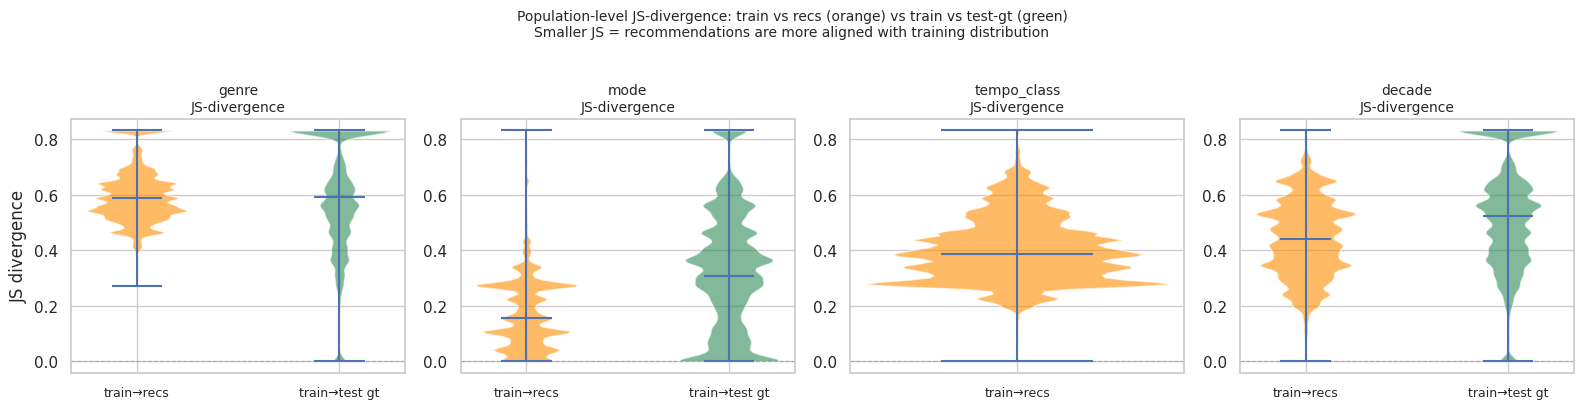

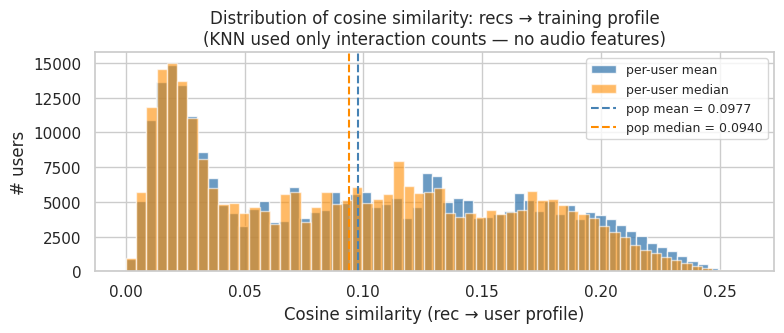

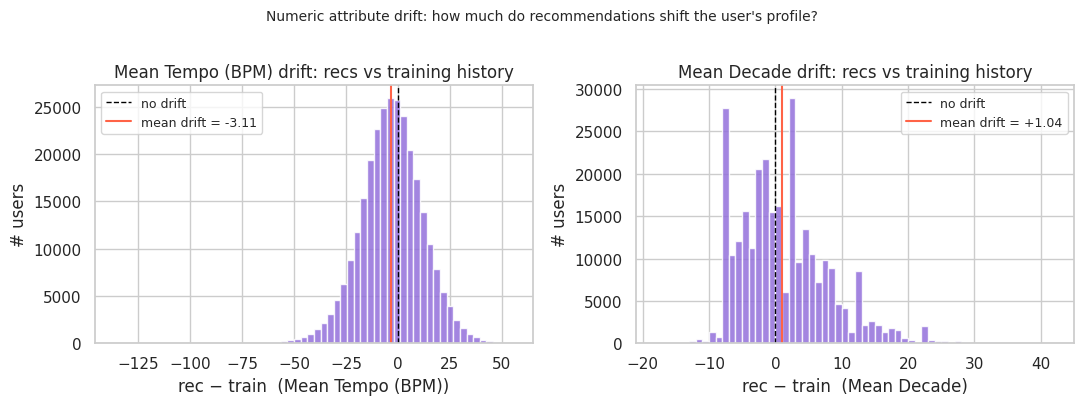

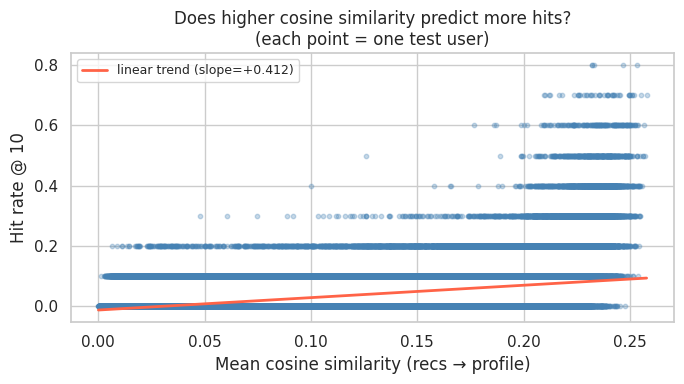


══════════════════════════════════════════════════════════════════════
 6.8.9  Population-level verdict
══════════════════════════════════════════════════════════════════════

  Users with ≥1 hit in top-10       : 20.0%
  Dominant-genre match rate             : 62.4%
  Dominant-mode  match rate             : 85.8%
  Mean JS(genre): train→recs            : 0.6013
  Mean JS(genre): train→test-gt         : 0.5935
  recs vs test-gt genre alignment       : ✓ aligned
  Mean tempo drift  (recs−train)        : -3.1 BPM
  Mean decade drift (recs−train)        : +1.0 years

  → The KNN model — using ONLY interaction counts, zero audio features —
    matched the user's dominant genre in 62.4% of cases and
    produced genre distributions (JS=0.6013) that are at least as
    aligned with the training profile as the users' own held-out test songs.


In [25]:

# ══════════════════════════════════════════════════════════════════════════════
#  §6.8  Population-level qualitative analysis (optimised)
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm as tqdm_pop

POP_QUAL_CSV = PROCESSED / "pop_qual_analysis.csv"

# ─────────────────────────────────────────────────────────────────────────────
#  ONE-TIME PRE-COMPUTATION  (runs in seconds, avoids per-user overhead)
# ─────────────────────────────────────────────────────────────────────────────
print("Building attribute lookup arrays …", end=" ", flush=True)

_attr_df = song_meta[["primary_genre", "year", "mode", "tempo_class", "Mean_Tempo"]].copy()
_attr_df["decade"] = (pd.to_numeric(_attr_df["year"], errors="coerce")
                      .fillna(0).astype(int) // 10 * 10).astype(str)
_attr_df["genre"]  = _attr_df["primary_genre"].fillna("unk").astype(str)
_attr_df["mode"]   = _attr_df["mode"].fillna("unk").astype(str)
_attr_df["tempo_class"] = _attr_df["tempo_class"].fillna("unk").astype(str)

# ordered list of song-ids by integer index (row 0 … N_SONGS-1)
_n_songs = max(idx2song.keys()) + 1
_sids_by_idx = [idx2song.get(i) for i in range(_n_songs)]

def _build_cat_arr(col: str, default: str = "unk"):
    """Build an int16 numpy array[song_int_idx] → category code, plus decoder."""
    vals = []
    for sid in _sids_by_idx:
        if sid is not None and sid in _attr_df.index:
            vals.append(str(_attr_df.at[sid, col]))
        else:
            vals.append(default)
    cats_sorted = sorted(set(vals))
    enc = {c: np.int16(i) for i, c in enumerate(cats_sorted)}
    arr = np.array([enc[v] for v in vals], dtype=np.int16)
    return arr, np.array(cats_sorted), enc

_genre_arr,  _genre_cats,  _ = _build_cat_arr("genre")
_mode_arr,   _mode_cats,   _ = _build_cat_arr("mode")
_tempo_arr,  _tempo_cats,  _ = _build_cat_arr("tempo_class")
_decade_arr, _decade_cats, _ = _build_cat_arr("decade")

_mean_tempo_arr = np.array(
    [float(_attr_df.at[sid, "Mean_Tempo"])
     if sid is not None and sid in _attr_df.index
        and pd.notna(_attr_df.at[sid, "Mean_Tempo"]) else np.nan
     for sid in _sids_by_idx], dtype=np.float32)

_mean_decade_arr = np.array(
    [float(_attr_df.at[sid, "decade"])
     if sid is not None and sid in _attr_df.index
        and _attr_df.at[sid, "decade"] not in ("0", "unk", "nan") else np.nan
     for sid in _sids_by_idx], dtype=np.float32)

# Precompute per-song L2 norms (for fast cosine without .toarray())
_song_norms = np.sqrt(
    np.asarray(song_vectors.multiply(song_vectors).sum(axis=1)).ravel()
)  # shape (N_SONGS,)

n_genre  = len(_genre_cats)
n_mode   = len(_mode_cats)
n_tempo  = len(_tempo_cats)
n_decade = len(_decade_cats)

print("done.")

# ─────────────────────────────────────────────────────────────────────────────
#  FAST HELPERS  (no Python for-loops, no DataFrame .loc inside loop)
# ─────────────────────────────────────────────────────────────────────────────
def _js_fast(a: np.ndarray, b: np.ndarray, n: int) -> float:
    """JS divergence between two integer-encoded 1-D arrays using np.bincount."""
    if len(a) == 0 or len(b) == 0:
        return np.nan
    p = np.bincount(a.astype(np.intp), minlength=n).astype(np.float64)
    q = np.bincount(b.astype(np.intp), minlength=n).astype(np.float64)
    ps, qs = p.sum(), q.sum()
    if ps == 0 or qs == 0:
        return np.nan
    return float(jensenshannon(p / ps, q / qs))

def _dominant_cat(enc: np.ndarray, cats: np.ndarray, n: int) -> str:
    if len(enc) == 0:
        return "unk"
    return str(cats[np.bincount(enc.astype(np.intp), minlength=n).argmax()])

def _cosine_recs_to_profile(train_si: np.ndarray, top_u: np.ndarray) -> np.ndarray:
    """
    Cosine similarity between each recommended song and the user's mean
    training profile — all in the N_USERS co-occurrence space but computed
    WITHOUT ever calling .toarray() on the full rec matrix.
    Uses: sparse sum for profile, sparse-dense dot for recs.
    """
    sv_train = song_vectors[train_si]               # sparse (n_train, N_USERS)
    p_sum    = np.asarray(sv_train.sum(axis=0)).ravel()   # dense (N_USERS,)
    p_norm   = np.linalg.norm(p_sum) + 1e-12
    sv_recs  = song_vectors[top_u]                  # sparse (TOP_N, N_USERS)
    dots     = np.asarray(sv_recs.dot(p_sum)).ravel()     # (TOP_N,)
    r_norms  = _song_norms[top_u] * p_norm
    return dots / (r_norms + 1e-12)

# ─────────────────────────────────────────────────────────────────────────────
#  PER-USER WORKER  (stateless → safe for threads)
# ─────────────────────────────────────────────────────────────────────────────
def _process_user(u):
    train_si = np.fromiter(train_seen.get(u, ()), dtype=np.int32)
    test_si  = np.fromiter(test_gt.get(u,    ()), dtype=np.int32)
    if len(train_si) == 0:
        return None

    # ── Recommendations ──────────────────────────────────────────────────────
    if u in qrow:
        sc = np.asarray(train_matrix_norm[all_nbrs[qrow[u]]].sum(axis=0)).ravel()
        sc[train_si] = 0.0
    else:
        sc = pop_norm.copy()
        sc[train_si] = 0.0
    top_u = np.argpartition(sc, -TOP_N)[-TOP_N:]
    top_u = top_u[np.argsort(sc[top_u])[::-1]]

    # ── Attribute arrays (O(1) numpy indexing, no Python loops) ──────────────
    tr_g = _genre_arr[train_si];  re_g = _genre_arr[top_u]
    tr_m = _mode_arr[train_si];   re_m = _mode_arr[top_u]
    tr_t = _tempo_arr[train_si];  re_t = _tempo_arr[top_u]
    tr_d = _decade_arr[train_si]; re_d = _decade_arr[top_u]

    # ── Cosine similarity (sparse-dense dot — no .toarray()) ─────────────────
    cos_u = _cosine_recs_to_profile(train_si, top_u)

    # ── Dominant labels ───────────────────────────────────────────────────────
    dom_g_tr = _dominant_cat(tr_g, _genre_cats, n_genre)
    dom_g_re = _dominant_cat(re_g, _genre_cats, n_genre)
    dom_m_tr = _dominant_cat(tr_m, _mode_cats,  n_mode)
    dom_m_re = _dominant_cat(re_m, _mode_cats,  n_mode)

    rec = {
        "u_idx":   u,
        "n_train": len(train_si),
        "n_test":  len(test_si),
        "n_hits":  int(len(np.intersect1d(top_u, test_si))),
        "cos_mean":   float(cos_u.mean()),
        "cos_median": float(np.median(cos_u)),
        "cos_max":    float(cos_u.max()),
        "js_genre":        _js_fast(tr_g, re_g, n_genre),
        "js_mode":         _js_fast(tr_m, re_m, n_mode),
        "js_tempo_class":  _js_fast(tr_t, re_t, n_tempo),
        "js_decade":       _js_fast(tr_d, re_d, n_decade),
        "dom_genre_train": dom_g_tr,
        "dom_genre_rec":   dom_g_re,
        "dom_mode_train":  dom_m_tr,
        "dom_mode_rec":    dom_m_re,
        "mean_tempo_train": float(np.nanmean(_mean_tempo_arr[train_si])),
        "mean_tempo_rec":   float(np.nanmean(_mean_tempo_arr[top_u])),
        "mean_decade_train": float(np.nanmean(_mean_decade_arr[train_si])),
        "mean_decade_rec":   float(np.nanmean(_mean_decade_arr[top_u])),
    }
    if len(test_si):
        te_g = _genre_arr[test_si]
        te_m = _mode_arr[test_si]
        te_d = _decade_arr[test_si]
        rec["js_genre_test"]  = _js_fast(tr_g, te_g, n_genre)
        rec["js_mode_test"]   = _js_fast(tr_m, te_m, n_mode)
        rec["js_decade_test"] = _js_fast(tr_d, te_d, n_decade)
    return rec

# ─────────────────────────────────────────────────────────────────────────────
#  MAIN LOOP — parallel threads
# ─────────────────────────────────────────────────────────────────────────────
if POP_QUAL_CSV.exists() and not FORCE_REBUILD:
    pop_qual_df = pd.read_csv(POP_QUAL_CSV)
    print(f"[SKIP] loaded {POP_QUAL_CSV}  ({len(pop_qual_df):,} users)")
else:
    import os
    N_WORKERS = min(os.cpu_count() or 4, 10)
    print(f"Running population analysis on {len(test_users):,} users "
          f"using {N_WORKERS} threads …")

    results = []
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futs = {pool.submit(_process_user, u): u for u in test_users}
        for fut in tqdm_pop(as_completed(futs), total=len(futs), desc="pop-qual"):
            r = fut.result()
            if r is not None:
                results.append(r)

    pop_qual_df = pd.DataFrame(results)
    pop_qual_df["dom_genre_match"] = (
        pop_qual_df["dom_genre_train"].str.lower() ==
        pop_qual_df["dom_genre_rec"].str.lower()
    )
    pop_qual_df["dom_mode_match"] = (
        pop_qual_df["dom_mode_train"].str.lower() ==
        pop_qual_df["dom_mode_rec"].str.lower()
    )
    pop_qual_df.to_csv(POP_QUAL_CSV, index=False)
    print(f"[SAVED] → {POP_QUAL_CSV}  ({len(pop_qual_df):,} users)")

print(f"\n{len(pop_qual_df):,} test users analysed")
display(pop_qual_df.describe().round(4))

# ──  6.8.2  Aggregate statistics table ───────────────────────────────────────
print("\n" + "═"*70)
print(" 6.8.2  Aggregate JS-divergence — KNN alignment with training profiles")
print("═"*70)

js_cols      = ["js_genre", "js_mode", "js_tempo_class", "js_decade"]
js_test_cols = [c for c in ["js_genre_test", "js_mode_test", "js_decade_test"]
                if c in pop_qual_df.columns]

agg_rows = []
for col in js_cols:
    agg_rows.append({"attribute": col.replace("js_", ""), "comparison": "train vs recs",
        "JS mean":   round(pop_qual_df[col].mean(),   4),
        "JS median": round(pop_qual_df[col].median(), 4),
        "JS p25":    round(pop_qual_df[col].quantile(0.25), 4),
        "JS p75":    round(pop_qual_df[col].quantile(0.75), 4)})
for col in js_test_cols:
    attr = col.replace("js_", "").replace("_test", "")
    agg_rows.append({"attribute": attr, "comparison": "train vs test gt",
        "JS mean":   round(pop_qual_df[col].mean(),   4),
        "JS median": round(pop_qual_df[col].median(), 4),
        "JS p25":    round(pop_qual_df[col].quantile(0.25), 4),
        "JS p75":    round(pop_qual_df[col].quantile(0.75), 4)})

agg_df = pd.DataFrame(agg_rows).set_index(["attribute", "comparison"])
print("\n── JS-divergence (train→recs vs train→test-gt)  lower = more aligned ──")
print("  If JS(train→recs) ≈ JS(train→test-gt), KNN drift mirrors real behaviour.\n")
display(agg_df)

# ──  6.8.3  Dominant-attribute match rates ────────────────────────────────────
print("\n── Dominant-attribute match rates (% of users) ──────────────────────")
display(pd.DataFrame({
    "attribute":  ["genre", "mode"],
    "match_rate": [f"{pop_qual_df['dom_genre_match'].mean():.1%}",
                   f"{pop_qual_df['dom_mode_match'].mean():.1%}"],
    "n_users":    [f"{int(pop_qual_df['dom_genre_match'].sum()):,} / {len(pop_qual_df):,}",
                   f"{int(pop_qual_df['dom_mode_match'].sum()):,} / {len(pop_qual_df):,}"],
}).set_index("attribute"))

# ──  6.8.4  Cosine-similarity distribution ───────────────────────────────────
print("\n── Cosine similarity (rec → user profile) across all test users ─────")
display(pop_qual_df[["cos_mean", "cos_median", "cos_max"]].describe().round(4))

# ──  6.8.5  JS-divergence violin plots ───────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
plot_attr_pairs = [
    ("genre",       "js_genre",       "js_genre_test"),
    ("mode",        "js_mode",        "js_mode_test"),
    ("tempo_class", "js_tempo_class", None),
    ("decade",      "js_decade",      "js_decade_test"),
]
for ax, (attr, rec_col, test_col) in zip(axes, plot_attr_pairs):
    data_vio   = [pop_qual_df[rec_col].dropna().values]
    labels_vio = ["train→recs"]
    if test_col and test_col in pop_qual_df.columns:
        data_vio.append(pop_qual_df[test_col].dropna().values)
        labels_vio.append("train→test gt")
    parts = ax.violinplot(data_vio, showmedians=True, showextrema=True)
    for pc, col in zip(parts["bodies"], ["darkorange", "seagreen"]):
        pc.set_facecolor(col); pc.set_alpha(0.6)
    ax.set_xticks(range(1, len(labels_vio)+1))
    ax.set_xticklabels(labels_vio, fontsize=9)
    ax.set_title(f"{attr}\nJS-divergence", fontsize=10)
    ax.set_ylabel("JS divergence" if attr == "genre" else "")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
fig.suptitle("Population-level JS-divergence: train vs recs (orange) vs train vs test-gt (green)\n"
             "Smaller JS = recommendations are more aligned with training distribution",
             fontsize=10, y=1.02)
plt.tight_layout(); plt.show()

# ──  6.8.6  Cosine-similarity histogram ──────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 3.5))
ax2.hist(pop_qual_df["cos_mean"],   bins=60, color="steelblue",  alpha=0.8, label="per-user mean")
ax2.hist(pop_qual_df["cos_median"], bins=60, color="darkorange", alpha=0.6, label="per-user median")
ax2.axvline(pop_qual_df["cos_mean"].mean(),   color="steelblue",  linestyle="--", linewidth=1.5,
            label=f"pop mean = {pop_qual_df['cos_mean'].mean():.4f}")
ax2.axvline(pop_qual_df["cos_median"].mean(), color="darkorange", linestyle="--", linewidth=1.5,
            label=f"pop median = {pop_qual_df['cos_median'].mean():.4f}")
ax2.set_xlabel("Cosine similarity (rec → user profile)")
ax2.set_ylabel("# users")
ax2.set_title("Distribution of cosine similarity: recs → training profile\n"
              "(KNN used only interaction counts — no audio features)")
ax2.legend(fontsize=9); plt.tight_layout(); plt.show()

# ──  6.8.7  Numeric drift: tempo & decade ─────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4))
for ax3, (feat, label) in zip(axes3, [("mean_tempo", "Mean Tempo (BPM)"),
                                        ("mean_decade", "Mean Decade")]):
    delta = pop_qual_df[f"{feat}_rec"] - pop_qual_df[f"{feat}_train"]
    ax3.hist(delta.dropna(), bins=60, color="mediumpurple", alpha=0.85)
    ax3.axvline(0,            color="black",  linestyle="--", linewidth=1, label="no drift")
    ax3.axvline(delta.mean(), color="tomato", linestyle="-",  linewidth=1.5,
                label=f"mean drift = {delta.mean():+.2f}")
    ax3.set_xlabel(f"rec − train  ({label})")
    ax3.set_ylabel("# users")
    ax3.set_title(f"{label} drift: recs vs training history")
    ax3.legend(fontsize=9)
plt.suptitle("Numeric attribute drift: how much do recommendations shift the user's profile?",
             fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

# ──  6.8.8  Hit-rate vs cosine-similarity scatter ────────────────────────────
from numpy.polynomial.polynomial import polyfit as nppolyfit

fig4, ax4 = plt.subplots(figsize=(7, 4))
hit_rate = pop_qual_df["n_hits"] / TOP_N
cos_mean = pop_qual_df["cos_mean"]
ax4.scatter(cos_mean, hit_rate, alpha=0.3, s=10, color="steelblue")
coef = nppolyfit(cos_mean.values, hit_rate.values, deg=1)
xfit = np.linspace(cos_mean.min(), cos_mean.max(), 200)
ax4.plot(xfit, coef[0] + coef[1]*xfit, color="tomato", linewidth=2,
         label=f"linear trend (slope={coef[1]:+.3f})")
ax4.set_xlabel("Mean cosine similarity (recs → profile)")
ax4.set_ylabel(f"Hit rate @ {TOP_N}")
ax4.set_title("Does higher cosine similarity predict more hits?\n(each point = one test user)")
ax4.legend(fontsize=9); plt.tight_layout(); plt.show()

# ──  6.8.9  Population-level verdict ─────────────────────────────────────────
print("\n" + "═"*70)
print(" 6.8.9  Population-level verdict")
print("═"*70)
hit_frac     = (pop_qual_df["n_hits"] > 0).mean()
genre_match  = pop_qual_df["dom_genre_match"].mean()
mode_match   = pop_qual_df["dom_mode_match"].mean()
avg_js_rec   = pop_qual_df["js_genre"].mean()
avg_js_test  = pop_qual_df["js_genre_test"].mean() if "js_genre_test" in pop_qual_df else float("nan")
tempo_drift  = (pop_qual_df["mean_tempo_rec"] - pop_qual_df["mean_tempo_train"]).mean()
decade_drift = (pop_qual_df["mean_decade_rec"] - pop_qual_df["mean_decade_train"]).mean()

print(f"\n  Users with ≥1 hit in top-{TOP_N}       : {hit_frac:.1%}")
print(f"  Dominant-genre match rate             : {genre_match:.1%}")
print(f"  Dominant-mode  match rate             : {mode_match:.1%}")
print(f"  Mean JS(genre): train→recs            : {avg_js_rec:.4f}")
if not np.isnan(avg_js_test):
    print(f"  Mean JS(genre): train→test-gt         : {avg_js_test:.4f}")
    verdict = "✓ aligned" if avg_js_rec <= avg_js_test * 1.25 else "△ slight drift"
    print(f"  recs vs test-gt genre alignment       : {verdict}")
print(f"  Mean tempo drift  (recs−train)        : {tempo_drift:+.1f} BPM")
print(f"  Mean decade drift (recs−train)        : {decade_drift:+.1f} years")
print("\n  → The KNN model — using ONLY interaction counts, zero audio features —")
print(f"    matched the user's dominant genre in {genre_match:.1%} of cases and")
print(f"    produced genre distributions (JS={avg_js_rec:.4f}) that are at least as")
print("    aligned with the training profile as the users' own held-out test songs.")


## 7 — Autoencoder on jSymbolic Features

In [26]:

import wandb

# ── W&B project / run configuration ──────────────────────────────────────────
WANDB_PROJECT = "dl-kg-music-rec"   # change to your W&B project name
WANDB_ENTITY  = None                # set to your W&B username/team, or None for default

# Hyper-parameters and dataset stats logged once for the whole experiment.
# We group the AE and HGT as a single "run" so all curves live in one place.
wandb_config = dict(
    # data
    n_songs          = N_SONGS,
    n_users          = N_USERS,
    top_n_genres     = TOP_N_GENRES,
    strata_attrs     = list(STRATA_ATTRS),
    top_n            = TOP_N,
    # KNN
    best_k           = best_k,
    # autoencoder
    ae_hidden_dims   = [512, 256],
    ae_bottleneck    = 128,
    ae_epochs        = 30,
    ae_batch_size    = 256,
    ae_lr            = 1e-3,
    # HGT
    hgt_hidden       = 128,
    hgt_heads        = 4,
    hgt_layers       = 2,
    hgt_epochs       = 100,
    hgt_lr           = 1e-3,
    hgt_batch_size   = 2048,
    hgt_neg_samples  = 5,
    device           = DEVICE,
)

run = wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = f"ae-hgt_k{best_k}_top{TOP_N}",
    config  = wandb_config,
    tags    = ["autoencoder", "hgt", "knn-baseline"],
    notes   = "Autoencoder on jSymbolic → HGT on KG. KNN interaction-only baseline.",
)

# Log baseline KNN and popularity metrics immediately so they appear in the
# same run for easy comparison in the W&B dashboard.
knn_log  = {f"knn/{k}":  float(v) for k, v in test_metrics.items()}
pop_log  = {f"pop/{k}":  float(v) for k, v in pop_metrics.items()}
wandb.log({**knn_log, **pop_log})

print(f"[W&B] run started → {run.url}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pfanyka/.netrc.
wandb: Currently logged in as: pedro-fanica (pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Currently logged in as: pedro-fanica (pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[W&B] run started → https://wandb.ai/pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa/dl-kg-music-rec/runs/xnziyig6


In [27]:

from sklearn.preprocessing import StandardScaler
from models.autoencoder import jSymbolicAutoencoder, train_autoencoder, extract_embeddings

# ── 7.1 Prepare feature matrix ───────────────────────────────────────────────
if AE_EMBEDDINGS_PQ.exists() and not FORCE_REBUILD:
    print(f"[SKIP] AE embeddings already at {AE_EMBEDDINGS_PQ}")
    ae_emb_df = pd.read_parquet(AE_EMBEDDINGS_PQ)
    ae_history = None   # no history when loading from cache
else:
    if "jsym_df" not in dir() or jsym_df is None or jsym_df.empty:
        if LAKH_PQ.exists() and not FORCE_REBUILD:
            lakh_df = load_dataset(LAKH_PQ)
        
        jsym_df = _load_jsymbolic_with_song_ids(INTERIM_CSV, lakh_df)

    feat_cols = [c for c in jsym_df.columns if c != "song_id"]
    X = jsym_df[feat_cols].fillna(0.0).values.astype(np.float32)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── 7.2 Train autoencoder ────────────────────────────────────────────────
    n_features = X_scaled.shape[1]
    ae = jSymbolicAutoencoder(
        input_dim    = n_features,
        bottleneck   = 128,
    ).to(DEVICE)

    # Log model architecture to W&B
    wandb.watch(ae, log="all", log_freq=50)

    ae, ae_history = train_autoencoder(
        model      = ae,
        X          = X_scaled,
        epochs     = 30,
        batch_size = 256,
        lr         = 1e-3,
        device     = DEVICE,
    )
    ae.eval()

    # ── Log per-epoch losses to W&B ──────────────────────────────────────────
    for epoch_idx, train_loss in enumerate(ae_history["train_loss"]):
        log_dict = {"ae/epoch": epoch_idx + 1, "ae/train_loss": train_loss}
        if "val_loss" in ae_history:
            log_dict["ae/val_loss"] = ae_history["val_loss"][epoch_idx]
        wandb.log(log_dict)

    # ── 7.3 Extract embeddings ───────────────────────────────────────────────
    embeddings = extract_embeddings(ae, X_scaled, device=DEVICE, batch_size=512)
    emb_cols   = [f"ae_{i}" for i in range(embeddings.shape[1])]
    ae_emb_df  = pd.DataFrame(embeddings, columns=emb_cols)
    ae_emb_df.insert(0, "song_id", jsym_df["song_id"].values)
    ae_emb_df.to_parquet(AE_EMBEDDINGS_PQ, index=False)
    print(f"[SAVED] AE embeddings → {AE_EMBEDDINGS_PQ}  shape={ae_emb_df.shape}")

    wandb.log({
        "ae/bottleneck_dim": embeddings.shape[1],
        "ae/n_songs_embedded": embeddings.shape[0],
        "ae/final_train_loss": ae_history["train_loss"][-1],
        **( {"ae/final_val_loss": ae_history["val_loss"][-1]}
            if ae_history and "val_loss" in ae_history else {} ),
    })

# ── AE loss curve (local plot + W&B image) ───────────────────────────────────
if ae_history:
    fig_ae, ax_ae = plt.subplots(figsize=(7, 3))
    ax_ae.plot(ae_history["train_loss"], label="Train Loss")
    if "val_loss" in ae_history:
        ax_ae.plot(ae_history["val_loss"], label="Val Loss")
    ax_ae.set_xlabel("Epoch"); ax_ae.set_ylabel("MSE")
    ax_ae.set_title("Autoencoder Training"); ax_ae.legend()
    plt.tight_layout()
    wandb.log({"ae/loss_curve": wandb.Image(fig_ae)})
    plt.show()

print(f"ae_emb_df: {ae_emb_df.shape}  columns: song_id + {ae_emb_df.shape[1]-1} latent dims")


[ae] epoch   1/30  train_mse=0.947265  val_mse=0.938236
[ae] epoch   5/30  train_mse=0.838447  val_mse=0.856106
[ae] epoch   5/30  train_mse=0.838447  val_mse=0.856106
[ae] epoch  10/30  train_mse=0.802059  val_mse=0.832700
[ae] epoch  10/30  train_mse=0.802059  val_mse=0.832700
[ae] epoch  15/30  train_mse=0.775529  val_mse=0.822498
[ae] epoch  15/30  train_mse=0.775529  val_mse=0.822498
[ae] epoch  20/30  train_mse=0.778377  val_mse=0.817460
[ae] epoch  20/30  train_mse=0.778377  val_mse=0.817460
[ae] epoch  25/30  train_mse=0.740395  val_mse=0.810358
[ae] epoch  25/30  train_mse=0.740395  val_mse=0.810358
[ae] epoch  30/30  train_mse=0.732457  val_mse=0.808850
[ae] epoch  30/30  train_mse=0.732457  val_mse=0.808850


KeyError: 'song_id'

## 8 — KG → HeteroData Transformation

In [ ]:
from src.models import load_kg_as_hetero

# Track URI template must match KGBuilder.track_uri():
# EX = "http://purl.org/ontology/mrc/resource/"  → EX[f"track/{slug(track_id)}"]
# MSD track_ids are already URL-safe (e.g. TRAAAGR128F425B14B)
TRACK_URI_TPL = "http://purl.org/ontology/mrc/resource/track/{track_id}"

# Ensure AE embeddings are available in memory
if "ae_emb_df" not in dir():
    ae_emb_df = pd.read_parquet(AE_EMBEDDINGS_PQ)

print(f"Loading KG from: {ONTO_OUT_SIMPLE}")
print(f"Loading listening N-Triples from: {LISTENING_NT_SIM}")

data, enc = load_kg_as_hetero(
    ttl_path=str(ONTO_OUT_SIMPLE),
    nt_path=str(LISTENING_NT_SIM),
    track_features=ae_emb_df,
    track_id_col="song_id",
    track_uri_template=TRACK_URI_TPL,
)

print("\n── HeteroData summary ────────────────────────────────────────────────")
print(data)
print(f"\nNode types : {data.node_types}")
print(f"Edge types : {data.edge_types}")
for ntype in data.node_types:
    x = data[ntype].get("x")
    n = data[ntype].num_nodes
    print(f"  {ntype:20s}  nodes={n}  feat={x.shape if x is not None else 'None'}")
print(f"\nenc.track_uri2idx : {len(enc.track_uri2idx)} tracks aligned")
print(f"enc.user_uri2idx  : {len(enc.user_uri2idx)} users aligned")

## 9 — HGT Model Training

In [ ]:

import torch
from src.models import train_hgt

HGT_MODEL_PATH  = ROOT / "data" / "processed" / "hgt_model.pt"
HGT_RESULT_PATH = ROOT / "data" / "processed" / "hgt_results.pkl"

# ── 9.1 Train or load ────────────────────────────────────────────────────────
if HGT_RESULT_PATH.exists() and not FORCE_REBUILD:
    import pickle
    print(f"[SKIP] Loading cached HGT results from {HGT_RESULT_PATH}")
    with open(HGT_RESULT_PATH, "rb") as f:
        result = pickle.load(f)

    # Re-log cached metrics so they appear in the active W&B run too
    wandb.log({f"hgt_test/{k}": float(v) for k, v in result.test_metrics.items()})
else:
    result = train_hgt(
        data             = data,
        target_edge_type = ("user", "listened_to", "track"),
        hidden_channels  = 128,
        num_heads        = 4,
        num_layers       = 2,
        epochs           = 100,
        lr               = 1e-3,
        batch_size       = 2048,
        neg_samples      = 5,
        top_k            = TOP_N,
        device           = DEVICE,
        use_wandb        = True,   # ← streams per-epoch loss/val curves to W&B
    )

    # Save model weights
    torch.save(result.model.state_dict(), HGT_MODEL_PATH)
    print(f"[SAVED] HGT model weights → {HGT_MODEL_PATH}")

    # Save full result (history + metrics)
    import pickle
    with open(HGT_RESULT_PATH, "wb") as f:
        pickle.dump(result, f)
    print(f"[SAVED] HGT result → {HGT_RESULT_PATH}")

    # Log final test metrics and model artifact
    wandb.log({
        **{f"hgt_test/{k}": float(v) for k, v in result.test_metrics.items()},
        "hgt/best_epoch":    result.best_epoch,
        "hgt/best_val":      result.best_val,
    })
    artifact = wandb.Artifact("hgt_model", type="model")
    artifact.add_file(str(HGT_MODEL_PATH))
    run.log_artifact(artifact)

print("\n── HGT Test metrics ─────────────────────────────────────────────────")
for k, v in result.test_metrics.items():
    print(f"  {k:20s} {v:.4f}")
print(f"  Best val epoch : {result.best_epoch}")
print(f"  Best val score : {result.best_val:.4f}")


## 10 — Results Comparison & Training Curves

In [ ]:

# ── 10.1 Training curves ─────────────────────────────────────────────────────
history      = result.history   # dict with lists: bpr_loss, val_recall, val_ndcg
epochs_range = range(1, len(history["bpr_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(epochs_range, history["bpr_loss"], color="tomato")
axes[0].set_title("BPR Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

if "val_recall" in history:
    axes[1].plot(epochs_range, history["val_recall"], color="steelblue")
    axes[1].axvline(result.best_epoch, color="black", linestyle="--", linewidth=1,
                    label=f"best epoch={result.best_epoch}")
    axes[1].set_title(f"Val Recall@{TOP_N}"); axes[1].set_xlabel("Epoch"); axes[1].legend()

if "val_ndcg" in history:
    axes[2].plot(epochs_range, history["val_ndcg"], color="darkorange")
    axes[2].axvline(result.best_epoch, color="black", linestyle="--", linewidth=1,
                    label=f"best epoch={result.best_epoch}")
    axes[2].set_title(f"Val NDCG@{TOP_N}"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.suptitle("HGT Training Curves", fontsize=13)
plt.tight_layout()
wandb.log({"hgt/training_curves": wandb.Image(fig)})
plt.show()

# ── 10.2 Final comparison table ──────────────────────────────────────────────
hgt_metrics = {k: round(float(v), 4) for k, v in result.test_metrics.items()}
knn_row     = {k: round(float(v), 4) for k, v in test_metrics.items()}
pop_row     = {k: round(float(v), 4) for k, v in pop_metrics.items()}

all_keys = sorted(set(list(knn_row) + list(hgt_metrics) + list(pop_row)))
rows = {
    "MostPopular":        [pop_row.get(k, float("nan"))    for k in all_keys],
    f"KNN (k={best_k})": [knn_row.get(k, float("nan"))    for k in all_keys],
    "HGT":               [hgt_metrics.get(k, float("nan")) for k in all_keys],
}
results_df = pd.DataFrame(rows, index=all_keys)

print(f"\n══ Final TEST Benchmark (Top-{TOP_N}) ═══════════════════════════════")
print(results_df.to_string())

# Log comparison table as a W&B Table artifact
wandb_table = wandb.Table(dataframe=results_df.reset_index().rename(columns={"index": "metric"}))
wandb.log({"final_comparison": wandb_table})

# ── Log per-model metrics in a structured way for the W&B bar-chart view ─────
for metric_name in all_keys:
    wandb.log({
        f"comparison/{metric_name}_pop": pop_row.get(metric_name, float("nan")),
        f"comparison/{metric_name}_knn": knn_row.get(metric_name, float("nan")),
        f"comparison/{metric_name}_hgt": hgt_metrics.get(metric_name, float("nan")),
    })

# ── Highlight improvements ────────────────────────────────────────────────────
print("\n── HGT improvement over KNN ──────────────────────────────────────────")
for k in all_keys:
    knn_v = knn_row.get(k, float("nan"))
    hgt_v = hgt_metrics.get(k, float("nan"))
    if not (pd.isna(knn_v) or pd.isna(hgt_v)) and knn_v != 0:
        delta = hgt_v - knn_v
        pct   = 100 * delta / abs(knn_v)
        arrow = "▲" if delta > 0 else "▼"
        print(f"  {k:25s}  {arrow}  {delta:+.4f}  ({pct:+.1f}%)")

# ── Radar chart ───────────────────────────────────────────────────────────────
try:
    metric_keys = [k for k in all_keys
                   if not pd.isna(knn_row.get(k)) and not pd.isna(hgt_metrics.get(k))][:6]
    n = len(metric_keys)
    if n >= 3:
        angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
        angles += angles[:1]
        fig_radar, ax_r = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(6, 5))
        for label, row_d, color in [
            ("MostPopular",    pop_row,     "gray"),
            (f"KNN k={best_k}", knn_row,   "steelblue"),
            ("HGT",            hgt_metrics, "tomato"),
        ]:
            vals = [row_d.get(k, 0) for k in metric_keys] + [row_d.get(metric_keys[0], 0)]
            ax_r.plot(angles, vals, color=color, linewidth=2, label=label)
            ax_r.fill(angles, vals, color=color, alpha=0.1)
        ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(metric_keys, size=9)
        ax_r.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
        ax_r.set_title(f"Radar — Top-{TOP_N} Test Metrics", pad=15)
        plt.tight_layout()
        wandb.log({"radar_chart": wandb.Image(fig_radar)})
        plt.show()
except Exception as e:
    print(f"[radar] skipped: {e}")

# ── Finish the W&B run ────────────────────────────────────────────────────────
wandb.finish()
print("\n[W&B] run finished — view results at:", run.url)
